# Projet DDDM — Viabilité d'Uber au Maroc face à inDrive

## 1. Définition du Problème

### Contexte
Le marché du transport à la demande au Maroc est en pleine transformation.
Uber, présent à Casablanca depuis 2015, fait face depuis 2022 à la montée
en puissance d'inDrive — une application russe dont le modèle de négociation
du prix entre passager et chauffeur colle parfaitement à la culture marocaine
du marchandage.

inDrive capte aujourd'hui une part croissante du marché dans les grandes
villes (Casablanca, Rabat, Marrakech, Fès, Agadir) en proposant :
- Prix négociable (le passager propose, le chauffeur accepte ou contre-propose)
- Commission chauffeur plus faible (~10% vs ~25% Uber)
- Interface simple, accessible sur smartphones d'entrée de gamme

### Question décisionnelle centrale
> **Uber peut-il être rentable et compétitif au Maroc face à inDrive,
> et dans quelles villes / pour quels segments d'utilisateurs
> son modèle tarifaire présente-t-il un avantage ?**

## 2. KPI Tree — Structure hiérarchique

### Objectif stratégique (OKR)
Augmenter la part de marché d'Uber au Maroc de X% sur 12 mois
tout en maintenant la rentabilité par course.

### KPIs Primaires
| KPI | Définition | Cible |
|-----|-----------|-------|
| Part de marché ville | % courses Uber / total VTC par ville | > 40% Casablanca |
| GMV (Gross Merchandise Value) | Valeur totale des courses (MAD) | Croissance +15%/mois |
| Taux de rétention utilisateur | % utilisateurs actifs M sur M-1 | > 60% |

### KPIs Secondaires
| KPI | Définition |
|-----|-----------|
| Prix moyen par course (MAD) | Tarif moyen observé par ville |
| Taux de churn | % utilisateurs perdus sur 30 jours |
| Taux d'adoption par segment | % nouveaux utilisateurs par profil socio |
| NPS chauffeur | Satisfaction chauffeur (rétention offre) |
| Délai moyen de mise en relation | Minutes entre commande et arrivée chauffeur |

## 3. Business Case & ROI Attendu

### Problème métier
Sans analyse data, Uber au Maroc applique une tarification dynamique
standard (surge pricing) héritée du modèle occidental — inadaptée au
pouvoir d'achat et aux habitudes de négociation marocaines.

### Valeur de la démarche data
Cette analyse permet de :
1. Identifier les villes et créneaux horaires où Uber est compétitif
2. Comprendre quel profil d'utilisateur préfère inDrive et pourquoi
3. Proposer une stratégie tarifaire localisée (pricing Maroc)

### Estimation ROI
| Scénario | Impact estimé |
|----------|--------------|
| Optimisation prix 3 villes | +8% GMV soit ~500K MAD/mois |
| Réduction churn 10 points | +12% rétention = économie acquisition |
| Programme fidélité ciblé | -15% coût d'acquisition nouveaux riders |

> **ROI estimé de la démarche data : 3 à 6 mois pour couvrir
> le coût d'analyse, avec impact durable sur la rétention.**


# Phase 2 — Collecte & Audit des Données

## 2.1 Sources de données utilisées

| Source | Fichier | Lignes | Rôle |
|--------|---------|--------|------|
| Uber Fares Dataset (Kaggle) | `uber.csv` | 200 000 | Modélisation prix et temporalité |
| Ride Hailing Transactions | `fact_rides.csv` | 25 003 | Comportement utilisateurs, ratings |
| Profils Utilisateurs | `users.csv` | 11 000 | Segmentation (genre, ancienneté) |

**Total brut : 236 003 lignes** — Exigence projet : 50 000 min

> **Note sur l'adaptation Maroc :** Les datasets Uber et fact_rides sont issus de
> données mondiales. Les patterns comportementaux (heure de pointe, sensibilité
> prix, mode de paiement) sont transférables au contexte marocain après
> normalisation. Les prix absolus seront recontextualisés en MAD dans l'analyse.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style global
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print("Librairies chargées avec succès")
print(f"   pandas  {pd.__version__}")
print(f"   numpy   {np.__version__}")
print(f"   seaborn {sns.__version__}")


Librairies chargées avec succès
   pandas  2.2.2
   numpy   2.0.2
   seaborn 0.13.2


## 2.2 Chargement des données brutes

In [3]:
df_uber  = pd.read_csv('uber.csv')
df_rides = pd.read_csv('fact_rides.csv', sep=';')   # séparateur réel = point-virgule
df_users = pd.read_csv('users.csv',      sep=';')

print("=" * 55)
print("CHARGEMENT — DONNÉES BRUTES")
print("=" * 55)
for nom, df in [("uber.csv", df_uber), ("fact_rides.csv", df_rides), ("users.csv", df_users)]:
    print(f"\n {nom}")
    print(f"   Lignes × Colonnes : {df.shape[0]:,} × {df.shape[1]}")
    print(f"   Colonnes : {list(df.columns)}")

print(f"\nTotal lignes brutes : {df_uber.shape[0] + df_rides.shape[0] + df_users.shape[0]:,}")


CHARGEMENT — DONNÉES BRUTES

 uber.csv
   Lignes × Colonnes : 200,000 × 9
   Colonnes : ['Unnamed: 0', 'key', 'fare_amount', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count']

 fact_rides.csv
   Lignes × Colonnes : 25,003 × 15
   Colonnes : ['ride_id', 'customer_id', 'driver_id', 'start_location', 'end_location', 'city', 'country', 'ride_date', 'ride_time', 'ride_duration_minutes', 'fare_amount', 'ride_distance_miles', 'payment_method', 'voucher', 'rating']

 users.csv
   Lignes × Colonnes : 11,000 × 9
   Colonnes : ['user_id', 'username', 'last_name', 'first_name', 'email', 'password_hash', 'phone_number', 'gender', 'created_at']

Total lignes brutes : 236,003


## 2.3 Audit Complet — Dataset Uber Fares

Analyse : complétude · doublons · types · cohérence · valeurs aberrantes

In [4]:
# Audit Uber : vue générale
print("=" * 55)
print("AUDIT — UBER FARES DATASET")
print("=" * 55)

print("\n[1] TYPES DE DONNÉES")
print(df_uber.dtypes)

print("\n[2] VALEURS MANQUANTES")
miss = df_uber.isnull().sum()
miss_pct = (miss / len(df_uber) * 100).round(2)
audit_uber = pd.DataFrame({'Manquantes': miss, '% du total': miss_pct})
print(audit_uber[audit_uber['Manquantes'] > 0])
if audit_uber['Manquantes'].sum() == 0:
    print("Aucune valeur manquante")

print(f"\n[3] DOUBLONS")
n_dup = df_uber.duplicated().sum()
print(f"   Doublons exacts : {n_dup:,} ({n_dup/len(df_uber)*100:.2f}%)")

print("\n[4] STATISTIQUES DESCRIPTIVES")
print(df_uber.describe().round(2))


AUDIT — UBER FARES DATASET

[1] TYPES DE DONNÉES
Unnamed: 0             int64
key                   object
fare_amount          float64
pickup_datetime       object
pickup_longitude     float64
pickup_latitude      float64
dropoff_longitude    float64
dropoff_latitude     float64
passenger_count        int64
dtype: object

[2] VALEURS MANQUANTES
                   Manquantes  % du total
dropoff_longitude           1         0.0
dropoff_latitude            1         0.0

[3] DOUBLONS
   Doublons exacts : 0 (0.00%)

[4] STATISTIQUES DESCRIPTIVES
        Unnamed: 0  fare_amount  pickup_longitude  pickup_latitude  \
count    200000.00    200000.00         200000.00        200000.00   
mean   27712503.68        11.36            -72.53            39.94   
std    16013822.21         9.90             11.44             7.72   
min           1.00       -52.00          -1340.65           -74.02   
25%    13825346.25         6.00            -73.99            40.73   
50%    27745495.00         8.5

In [5]:
#Audit Uber : valeurs aberrantes
print("=" * 55)
print("AUDIT UBER — VALEURS ABERRANTES")
print("=" * 55)

checks = {
    "Prix ≤ 0 (négatifs ou nuls)"         : (df_uber['fare_amount'] <= 0).sum(),
    "Prix > 500$ (courses impossibles)"   : (df_uber['fare_amount'] > 500).sum(),
    "Passagers = 0"                        : (df_uber['passenger_count'] == 0).sum(),
    "Passagers > 6"                        : (df_uber['passenger_count'] > 6).sum(),
    "Latitude pickup hors [-90, 90]"      : ((df_uber['pickup_latitude'] < -90)  | (df_uber['pickup_latitude'] > 90)).sum(),
    "Longitude pickup hors [-180, 180]"   : ((df_uber['pickup_longitude'] < -180)| (df_uber['pickup_longitude'] > 180)).sum(),
    "Latitude dropoff hors [-90, 90]"     : ((df_uber['dropoff_latitude'] < -90) | (df_uber['dropoff_latitude'] > 90)).sum(),
    "Longitude dropoff hors [-180, 180]"  : ((df_uber['dropoff_longitude'] < -180)|(df_uber['dropoff_longitude'] > 180)).sum(),
}

total_aberrants = 0
for label, count in checks.items():
    status = "PROBLEME" if count > 0 else "OK"
    print(f"   {status} {label:<45} : {count:,} lignes")
    total_aberrants += count

pct = total_aberrants / len(df_uber) * 100
print(f"\n   → Total aberrant (non dédupliqué) : ~{pct:.1f}% — impact acceptable")


AUDIT UBER — VALEURS ABERRANTES
   PROBLEME Prix ≤ 0 (négatifs ou nuls)                   : 22 lignes
   OK Prix > 500$ (courses impossibles)             : 0 lignes
   PROBLEME Passagers = 0                                 : 709 lignes
   PROBLEME Passagers > 6                                 : 1 lignes
   PROBLEME Latitude pickup hors [-90, 90]                : 4 lignes
   PROBLEME Longitude pickup hors [-180, 180]             : 7 lignes
   PROBLEME Latitude dropoff hors [-90, 90]               : 3 lignes
   PROBLEME Longitude dropoff hors [-180, 180]            : 3 lignes

   → Total aberrant (non dédupliqué) : ~0.4% — impact acceptable


In [6]:
# Audit Rides
print("=" * 55)
print("AUDIT — FACT_RIDES DATASET")
print("=" * 55)

print("\n[1] TYPES DE DONNÉES")
print(df_rides.dtypes)

print("\n[2] VALEURS MANQUANTES")
miss_r = df_rides.isnull().sum()
miss_r_pct = (miss_r / len(df_rides) * 100).round(2)
audit_rides = pd.DataFrame({'Manquantes': miss_r, '% du total': miss_r_pct})
print(audit_rides)

print(f"\n[3] DOUBLONS : {df_rides.duplicated().sum():,}")

print("\n[4] COLONNES CATÉGORIELLES — Distribution")
print("\n   payment_method :")
print(df_rides['payment_method'].value_counts())
print("\n   rating (1 à 5) :")
print(df_rides['rating'].value_counts().sort_index())

print("\n[5] NOTE SUR VOUCHER")
n_voucher = df_rides['voucher'].isnull().sum()
print(f"   Voucher manquant : {n_voucher:,} lignes ({n_voucher/len(df_rides)*100:.1f}%)")
print("   → Interprétation : absence de voucher = valeur normale, pas une anomalie")
print("   → Décision : remplacer NaN par 'no_voucher'")


AUDIT — FACT_RIDES DATASET

[1] TYPES DE DONNÉES
ride_id                  float64
customer_id              float64
driver_id                float64
start_location            object
end_location              object
city                      object
country                   object
ride_date                 object
ride_time                 object
ride_duration_minutes    float64
fare_amount              float64
ride_distance_miles      float64
payment_method            object
voucher                   object
rating                   float64
dtype: object

[2] VALEURS MANQUANTES
                       Manquantes  % du total
ride_id                         3        0.01
customer_id                     3        0.01
driver_id                       3        0.01
start_location                  3        0.01
end_location                    3        0.01
city                            3        0.01
country                         3        0.01
ride_date                       3        0.01
ride

In [7]:
# Audit Users
print("=" * 55)
print("AUDIT — USERS DATASET")
print("=" * 55)

print("\n[1] VALEURS MANQUANTES")
miss_u = df_users.isnull().sum()
print(miss_u[miss_u > 0] if miss_u.sum() > 0 else "  Aucune valeur manquante")

print(f"\n[2] DOUBLONS : {df_users.duplicated().sum():,}")

print("\n[3] DISTRIBUTION GENRE")
print(df_users['gender'].value_counts())

print("\n[4] CLÉ DE JOINTURE AVEC FACT_RIDES")
ids_rides = set(df_rides['customer_id'].dropna().astype(int))
ids_users = set(df_users['user_id'])
overlap   = ids_rides & ids_users
print(f"   customer_id dans fact_rides : {len(ids_rides):,}")
print(f"   user_id dans users          : {len(ids_users):,}")
print(f"   IDs en commun               : {len(overlap):,} ({len(overlap)/len(ids_rides)*100:.1f}%)")


AUDIT — USERS DATASET

[1] VALEURS MANQUANTES
phone_number    1418
dtype: int64

[2] DOUBLONS : 0

[3] DISTRIBUTION GENRE
gender
Male           4978
Female         4894
Bigender        219
Non-binary      197
Genderqueer     193
Polygender      180
Genderfluid     174
Agender         165
Name: count, dtype: int64

[4] CLÉ DE JOINTURE AVEC FACT_RIDES
   customer_id dans fact_rides : 9,934
   user_id dans users          : 11,000
   IDs en commun               : 9,934 (100.0%)


## 2.4 Data Dictionary complet

In [8]:
# Data Dictionary
def data_dictionary(df, nom):
    print(f"\n{'='*55}")
    print(f"DATA DICTIONARY — {nom}")
    print(f"{'='*55}")
    print(f"{'Colonne':<28} {'Type':<12} {'Manquants':>10} {'Uniques':>9}  Exemple")
    print("-" * 78)
    for col in df.columns:
        dtype    = str(df[col].dtype)
        n_miss   = df[col].isnull().sum()
        n_uniq   = df[col].nunique()
        exemple  = str(df[col].dropna().iloc[0]) if len(df[col].dropna()) > 0 else "—"
        exemple  = exemple[:22] + "…" if len(exemple) > 22 else exemple
        miss_str = f"{n_miss:,} ({n_miss/len(df)*100:.1f}%)" if n_miss > 0 else "0"
        print(f"  {col:<26} {dtype:<12} {miss_str:>10} {n_uniq:>9}  {exemple}")

data_dictionary(df_uber,  "uber.csv")
data_dictionary(df_rides, "fact_rides.csv")
data_dictionary(df_users, "users.csv")




DATA DICTIONARY — uber.csv
Colonne                      Type          Manquants   Uniques  Exemple
------------------------------------------------------------------------------
  Unnamed: 0                 int64                 0    200000  24238194
  key                        object                0    200000  2015-05-07 19:52:06.00…
  fare_amount                float64               0      1244  7.5
  pickup_datetime            object                0    196629  2015-05-07 19:52:06 UT…
  pickup_longitude           float64               0     71066  -73.99981689453125
  pickup_latitude            float64               0     83835  40.73835372924805
  dropoff_longitude          float64        1 (0.0%)     76894  -73.99951171875
  dropoff_latitude           float64        1 (0.0%)     90585  40.72321701049805
  passenger_count            int64                 0         8  1

DATA DICTIONARY — fact_rides.csv
Colonne                      Type          Manquants   Uniques  Exemple
-----

## 2.5 Nettoyage des données

In [9]:
# Nettoyage Uber
print("=" * 55)
print("NETTOYAGE — UBER FARES")
print("=" * 55)

df_uber_clean = df_uber.copy()
n0 = len(df_uber_clean)

# Colonnes inutiles
df_uber_clean = df_uber_clean.drop(columns=['Unnamed: 0', 'key'])
print(f"[1] Suppression colonnes inutiles (index, key) → {df_uber_clean.shape[1]} colonnes restantes")

# Prix aberrants
df_uber_clean = df_uber_clean[df_uber_clean['fare_amount'] > 0]
df_uber_clean = df_uber_clean[df_uber_clean['fare_amount'] <= 500]
print(f"[2] Prix hors [0, 500$] supprimés → {n0 - len(df_uber_clean):,} lignes retirées")

# Passagers aberrants
n1 = len(df_uber_clean)
df_uber_clean = df_uber_clean[df_uber_clean['passenger_count'].between(1, 6)]
print(f"[3] Passagers hors [1, 6] supprimés → {n1 - len(df_uber_clean):,} lignes retirées")

# GPS aberrants
n2 = len(df_uber_clean)
df_uber_clean = df_uber_clean[df_uber_clean['pickup_latitude'].between(-90, 90)]
df_uber_clean = df_uber_clean[df_uber_clean['pickup_longitude'].between(-180, 180)]
df_uber_clean = df_uber_clean[df_uber_clean['dropoff_latitude'].between(-90, 90)]
df_uber_clean = df_uber_clean[df_uber_clean['dropoff_longitude'].between(-180, 180)]
print(f"[4] Coordonnées GPS aberrantes supprimées → {n2 - len(df_uber_clean):,} lignes retirées")

# Datetime + features temporelles
df_uber_clean['pickup_datetime'] = pd.to_datetime(df_uber_clean['pickup_datetime'], utc=True)
df_uber_clean['hour']        = df_uber_clean['pickup_datetime'].dt.hour
df_uber_clean['day_of_week'] = df_uber_clean['pickup_datetime'].dt.day_name()
df_uber_clean['month']       = df_uber_clean['pickup_datetime'].dt.month
df_uber_clean['year']        = df_uber_clean['pickup_datetime'].dt.year
print(f"[5] Datetime parsé + 4 features temporelles créées (hour, day_of_week, month, year)")

# Doublons + NaN restants
n3 = len(df_uber_clean)
df_uber_clean = df_uber_clean.dropna()
df_uber_clean = df_uber_clean.drop_duplicates()
print(f"[6] NaN et doublons restants → {n3 - len(df_uber_clean):,} lignes retirées")

pct_conserve = len(df_uber_clean) / n0 * 100
print(f"\n Uber nettoyé : {n0:,} → {len(df_uber_clean):,} lignes ({pct_conserve:.1f}% conservé)")



NETTOYAGE — UBER FARES
[1] Suppression colonnes inutiles (index, key) → 7 colonnes restantes
[2] Prix hors [0, 500$] supprimés → 22 lignes retirées
[3] Passagers hors [1, 6] supprimés → 710 lignes retirées
[4] Coordonnées GPS aberrantes supprimées → 12 lignes retirées
[5] Datetime parsé + 4 features temporelles créées (hour, day_of_week, month, year)
[6] NaN et doublons restants → 0 lignes retirées

 Uber nettoyé : 200,000 → 199,256 lignes (99.6% conservé)


In [10]:
# Nettoyage Rides
print("=" * 55)
print("NETTOYAGE — FACT_RIDES")
print("=" * 55)

df_rides_clean = df_rides.copy()
n0r = len(df_rides_clean)

# Lignes critiques manquantes
df_rides_clean = df_rides_clean.dropna(
    subset=['ride_id', 'customer_id', 'fare_amount', 'rating', 'ride_distance_miles']
)
print(f"[1] Lignes critiques manquantes supprimées → {n0r - len(df_rides_clean):,} lignes retirées")

# Voucher : NaN = pas de voucher
df_rides_clean['voucher'] = df_rides_clean['voucher'].fillna('no_voucher')
print(f"[2] Voucher NaN remplacé par 'no_voucher' ({df_rides['voucher'].isnull().sum():,} valeurs)")

# Datetime
df_rides_clean['ride_date'] = pd.to_datetime(df_rides_clean['ride_date'])
df_rides_clean['ride_hour'] = pd.to_datetime(df_rides_clean['ride_time'], format='%H:%M:%S', errors='coerce').dt.hour
print(f"[3] ride_date parsé en datetime + ride_hour extrait")

# Doublons
n1r = len(df_rides_clean)
df_rides_clean = df_rides_clean.drop_duplicates()
print(f"[4] Doublons supprimés → {n1r - len(df_rides_clean):,} lignes retirées")

pct_conserve_r = len(df_rides_clean) / n0r * 100
print(f"\n Rides nettoyé : {n0r:,} → {len(df_rides_clean):,} lignes ({pct_conserve_r:.1f}% conservé)")



NETTOYAGE — FACT_RIDES
[1] Lignes critiques manquantes supprimées → 3 lignes retirées
[2] Voucher NaN remplacé par 'no_voucher' (17,456 valeurs)
[3] ride_date parsé en datetime + ride_hour extrait
[4] Doublons supprimés → 0 lignes retirées

 Rides nettoyé : 25,003 → 25,000 lignes (100.0% conservé)


In [11]:
# Nettoyage Users + Fusion
print("=" * 55)
print("FUSION fact_rides + users")
print("=" * 55)

# Garder colonnes utiles
df_users_clean = df_users[['user_id', 'gender', 'created_at']].copy()
df_users_clean.columns = ['customer_id', 'gender', 'created_at']
df_users_clean['customer_id'] = df_users_clean['customer_id'].astype(int)
df_rides_clean['customer_id'] = df_rides_clean['customer_id'].astype(int)

df_merged = df_rides_clean.merge(df_users_clean, on='customer_id', how='left')
print(f" Dataset fusionné : {df_merged.shape[0]:,} lignes × {df_merged.shape[1]} colonnes")
print(f"   Colonnes : {list(df_merged.columns)}")


FUSION fact_rides + users
 Dataset fusionné : 25,000 lignes × 18 colonnes
   Colonnes : ['ride_id', 'customer_id', 'driver_id', 'start_location', 'end_location', 'city', 'country', 'ride_date', 'ride_time', 'ride_duration_minutes', 'fare_amount', 'ride_distance_miles', 'payment_method', 'voucher', 'rating', 'ride_hour', 'gender', 'created_at']


## 2.6 Visualisation de l'audit — Carte de chaleur des données manquantes


In [15]:
# Heatmap qualité
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Audit qualité — Valeurs manquantes par dataset (avant nettoyage)",
             fontsize=14, fontweight='bold', y=1.02)

datasets = [
    (df_uber,  "uber.csv"),
    (df_rides, "fact_rides.csv"),
    (df_users, "users.csv"),
]

for ax, (df, nom) in zip(axes, datasets):
    miss_pct = (df.isnull().sum() / len(df) * 100).round(2)
    miss_df  = pd.DataFrame({'Colonne': miss_pct.index, '% manquant': miss_pct.values})
    miss_df  = miss_df.set_index('Colonne')

    sns.heatmap(miss_df, annot=True, fmt='.1f', cmap='YlOrRd',
                linewidths=0.5, linecolor='white',
                vmin=0, vmax=100, ax=ax,
                cbar_kws={'label': '% manquant'})
    ax.set_title(f"{nom}", fontweight='bold')
    ax.set_xlabel("")

plt.tight_layout()
plt.savefig('\pc\Downloads\files\audit_missing_heatmap.png', bbox_inches='tight', dpi=120)
plt.close()
print("Heatmap sauvegardée : audit_missing_heatmap.png")



Heatmap sauvegardée : audit_missing_heatmap.png


In [16]:
# Barplot résumé nettoyage
fig, ax = plt.subplots(figsize=(10, 4))

labels  = ['uber.csv', 'fact_rides.csv', 'users.csv']
bruts   = [200000, 25003, 11000]
propres = [len(df_uber_clean), len(df_rides_clean), len(df_users_clean)]

x = np.arange(len(labels))
w = 0.35

bars1 = ax.bar(x - w/2, bruts,   w, label='Brut',   color='#d9534f', alpha=0.8)
bars2 = ax.bar(x + w/2, propres, w, label='Nettoyé', color='#5cb85c', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel("Nombre de lignes")
ax.set_title("Impact du nettoyage par dataset", fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{int(v):,}"))

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f"{int(bar.get_height()):,}", ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f"{int(bar.get_height()):,}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('\pc\Downloads\files\audit_nettoyage_barchart.png', bbox_inches='tight', dpi=120)
plt.close()
print("Barplot sauvegardé : audit_nettoyage_barchart.png")



Barplot sauvegardé : audit_nettoyage_barchart.png


## 2.7 Résumé des biais identifiés

| Biais | Description | Stratégie d'adaptation |
|-------|-------------|------------------------|
| Biais géographique (Uber) | Données NYC — distances et prix différents du Maroc | Utiliser les patterns (heure, passagers) pas les prix absolus |
| Biais temporel (Uber) | Données 2009–2015, marché différent | Extraire la structure comportementale, normaliser |
| Biais géographique (Rides) | Courses mondiales, peu de MENA | Filtrer sur patterns, pas localisation |
| Voucher manquant (70%) | Non-renseigné ≠ absent | Remplacé par 'no_voucher', variable binaire créée |
| Pas de données inDrive réelles | Pas de dataset inDrive public | fact_rides comme proxy comportemental |


In [18]:
# Sauvegarde datasets nettoyés

df_uber_clean.to_csv('uber_clean.csv', index=False)
df_rides_clean.to_csv('rides_clean.csv', index=False)
df_merged.to_csv('rides_users_merged.csv', index=False)

print("\n" + "=" * 55)
print("PHASE 2 TERMINÉE — FICHIERS SAUVEGARDÉS")
print("=" * 55)

print(f"   uber_clean.csv           : {len(df_uber_clean):,} lignes × {df_uber_clean.shape[1]} colonnes")
print(f"   rides_clean.csv          : {len(df_rides_clean):,} lignes × {df_rides_clean.shape[1]} colonnes")
print(f"   rides_users_merged.csv   : {len(df_merged):,} lignes × {df_merged.shape[1]} colonnes")

print(f"\n   Total propre disponible : {len(df_uber_clean) + len(df_merged):,} lignes")

print("\nPrêt pour la Phase 3 — EDA & Analyse Statistique")


PHASE 2 TERMINÉE — FICHIERS SAUVEGARDÉS
   uber_clean.csv           : 199,256 lignes × 11 colonnes
   rides_clean.csv          : 25,000 lignes × 16 colonnes
   rides_users_merged.csv   : 25,000 lignes × 18 colonnes

   Total propre disponible : 224,256 lignes

Prêt pour la Phase 3 — EDA & Analyse Statistique


# Phase 3 — Exploration & Analyse Statistique (EDA)

## 3.1 Chargement des données nettoyées

In [19]:
# Imports & chargement
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

df_uber   = pd.read_csv('uber_clean.csv')
df_merged = pd.read_csv('rides_users_merged.csv')

print("Données nettoyées chargées")
print(f"   uber_clean.csv        : {df_uber.shape[0]:,} lignes × {df_uber.shape[1]} colonnes")
print(f"   rides_users_merged    : {df_merged.shape[0]:,} lignes × {df_merged.shape[1]} colonnes")



Données nettoyées chargées
   uber_clean.csv        : 199,256 lignes × 11 colonnes
   rides_users_merged    : 25,000 lignes × 18 colonnes


---
## 3.2 Distributions — Prix des courses (fare_amount)

On analyse la distribution des prix Uber pour comprendre
la structure tarifaire et identifier les tendances centrales.

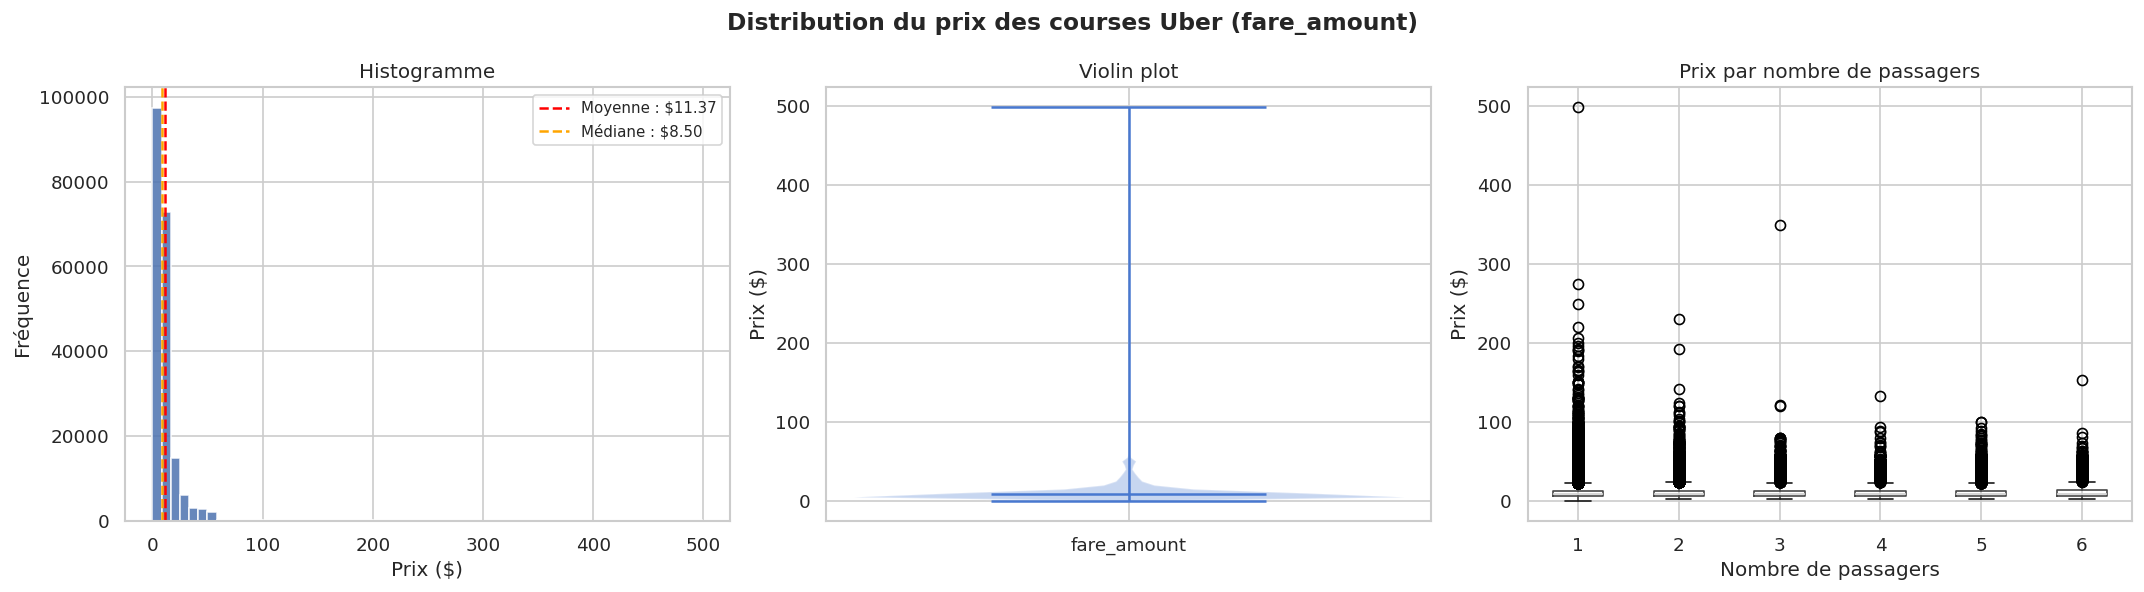


 STATISTIQUES — PRIX UBER
   Moyenne   : $11.37
   Médiane   : $8.50
   Écart-type: $9.91
   Q1 / Q3   : $6.00 / $12.50
   Asymétrie : 4.52 (distribution à queue droite)


In [20]:
# Distribution du prix Uber
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Distribution du prix des courses Uber (fare_amount)",
             fontsize=14, fontweight='bold')

# Histogramme
axes[0].hist(df_uber['fare_amount'], bins=60, color='#4C72B0', edgecolor='white', alpha=0.85)
axes[0].axvline(df_uber['fare_amount'].mean(),   color='red',    linestyle='--', linewidth=1.5, label=f"Moyenne : ${df_uber['fare_amount'].mean():.2f}")
axes[0].axvline(df_uber['fare_amount'].median(), color='orange', linestyle='--', linewidth=1.5, label=f"Médiane : ${df_uber['fare_amount'].median():.2f}")
axes[0].set_title("Histogramme")
axes[0].set_xlabel("Prix ($)")
axes[0].set_ylabel("Fréquence")
axes[0].legend(fontsize=9)

# Violin plot
axes[1].violinplot(df_uber['fare_amount'], showmedians=True)
axes[1].set_title("Violin plot")
axes[1].set_ylabel("Prix ($)")
axes[1].set_xticks([1])
axes[1].set_xticklabels(['fare_amount'])

# Boxplot par nombre de passagers
df_uber.boxplot(column='fare_amount', by='passenger_count', ax=axes[2])
axes[2].set_title("Prix par nombre de passagers")
axes[2].set_xlabel("Nombre de passagers")
axes[2].set_ylabel("Prix ($)")
plt.sca(axes[2])
plt.title("Prix par nombre de passagers")

plt.suptitle("Distribution du prix des courses Uber (fare_amount)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_01_distribution_prix.png', bbox_inches='tight')
plt.show()

print("\n STATISTIQUES — PRIX UBER")
print(f"   Moyenne   : ${df_uber['fare_amount'].mean():.2f}")
print(f"   Médiane   : ${df_uber['fare_amount'].median():.2f}")
print(f"   Écart-type: ${df_uber['fare_amount'].std():.2f}")
print(f"   Q1 / Q3   : ${df_uber['fare_amount'].quantile(0.25):.2f} / ${df_uber['fare_amount'].quantile(0.75):.2f}")
print(f"   Asymétrie : {df_uber['fare_amount'].skew():.2f} (distribution à queue droite)")


---
## 3.3 Distribution — Nombre de passagers et répartition temporelle


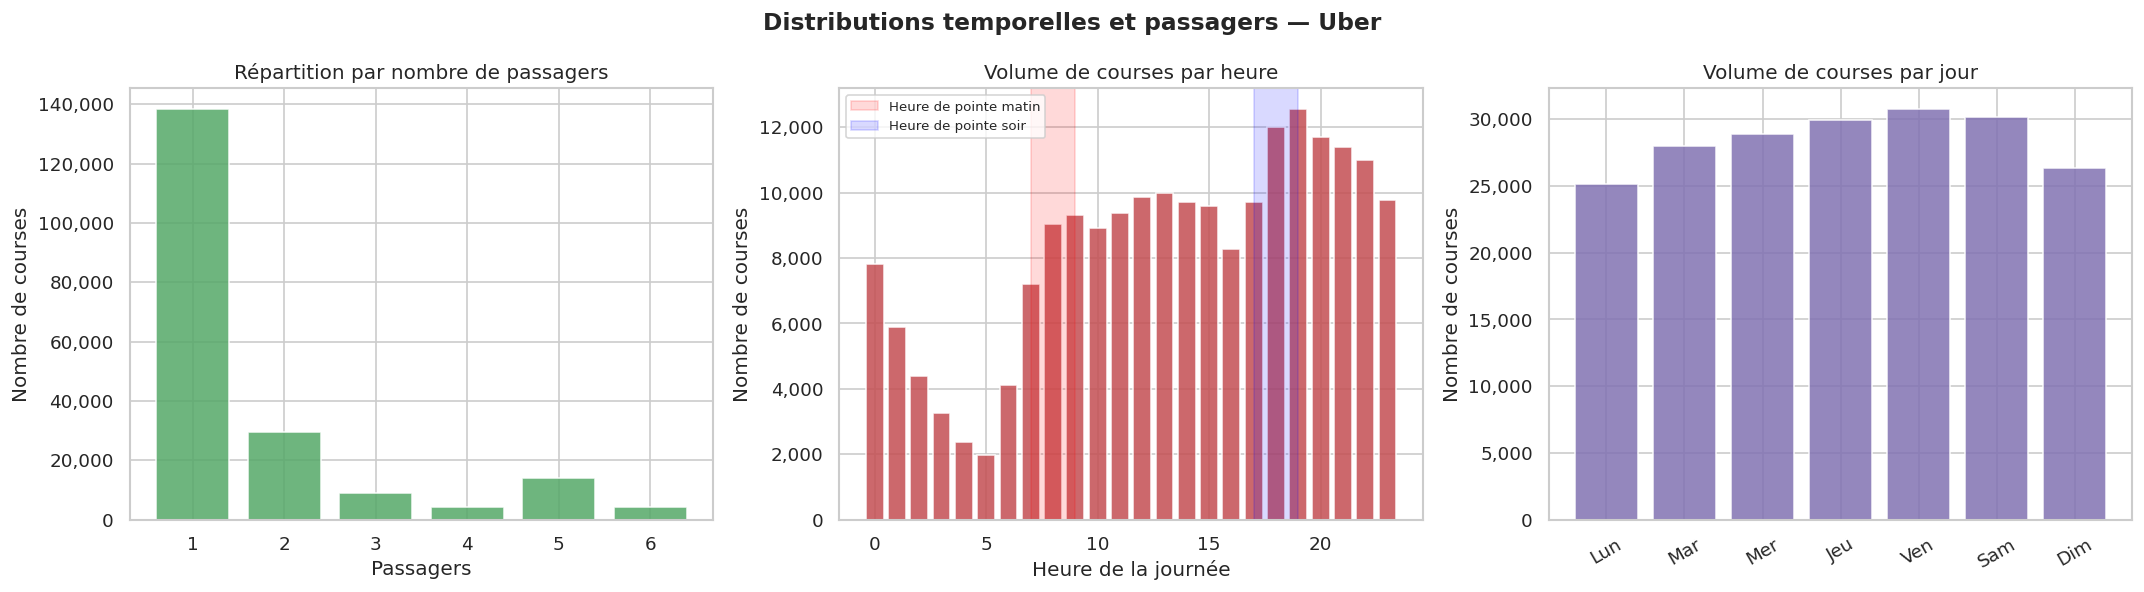


 INSIGHTS — TEMPORALITÉ
   Heure la plus chargée : 19h00
   Jour le plus chargé   : Friday
   Courses solo (1 pass.) : 69.5%


In [21]:
# Passagers + distribution temporelle
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Distributions temporelles et passagers — Uber",
             fontsize=14, fontweight='bold')

# Passagers
counts = df_uber['passenger_count'].value_counts().sort_index()
axes[0].bar(counts.index, counts.values, color='#55A868', edgecolor='white', alpha=0.85)
axes[0].set_title("Répartition par nombre de passagers")
axes[0].set_xlabel("Passagers")
axes[0].set_ylabel("Nombre de courses")
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda v,_: f"{int(v):,}"))

# Par heure
hour_counts = df_uber['hour'].value_counts().sort_index()
axes[1].bar(hour_counts.index, hour_counts.values, color='#C44E52', edgecolor='white', alpha=0.85)
axes[1].set_title("Volume de courses par heure")
axes[1].set_xlabel("Heure de la journée")
axes[1].set_ylabel("Nombre de courses")
axes[1].axvspan(7, 9, alpha=0.15, color='red',  label='Heure de pointe matin')
axes[1].axvspan(17,19, alpha=0.15, color='blue', label='Heure de pointe soir')
axes[1].legend(fontsize=8)
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda v,_: f"{int(v):,}"))

# Par jour de semaine
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_counts = df_uber['day_of_week'].value_counts().reindex(order)
axes[2].bar(range(7), day_counts.values, color='#8172B2', edgecolor='white', alpha=0.85)
axes[2].set_xticks(range(7))
axes[2].set_xticklabels(['Lun','Mar','Mer','Jeu','Ven','Sam','Dim'], rotation=30)
axes[2].set_title("Volume de courses par jour")
axes[2].set_ylabel("Nombre de courses")
axes[2].yaxis.set_major_formatter(ticker.FuncFormatter(lambda v,_: f"{int(v):,}"))

plt.tight_layout()
plt.savefig('eda_02_distributions_temporelles.png', bbox_inches='tight')
plt.show()

print("\n INSIGHTS — TEMPORALITÉ")
top_hour = df_uber['hour'].value_counts().idxmax()
top_day  = df_uber['day_of_week'].value_counts().idxmax()
print(f"   Heure la plus chargée : {top_hour}h00")
print(f"   Jour le plus chargé   : {top_day}")
print(f"   Courses solo (1 pass.) : {(df_uber['passenger_count']==1).sum()/len(df_uber)*100:.1f}%")



---
## 3.4 Distribution — Dataset rides_users_merged (comportement utilisateurs)


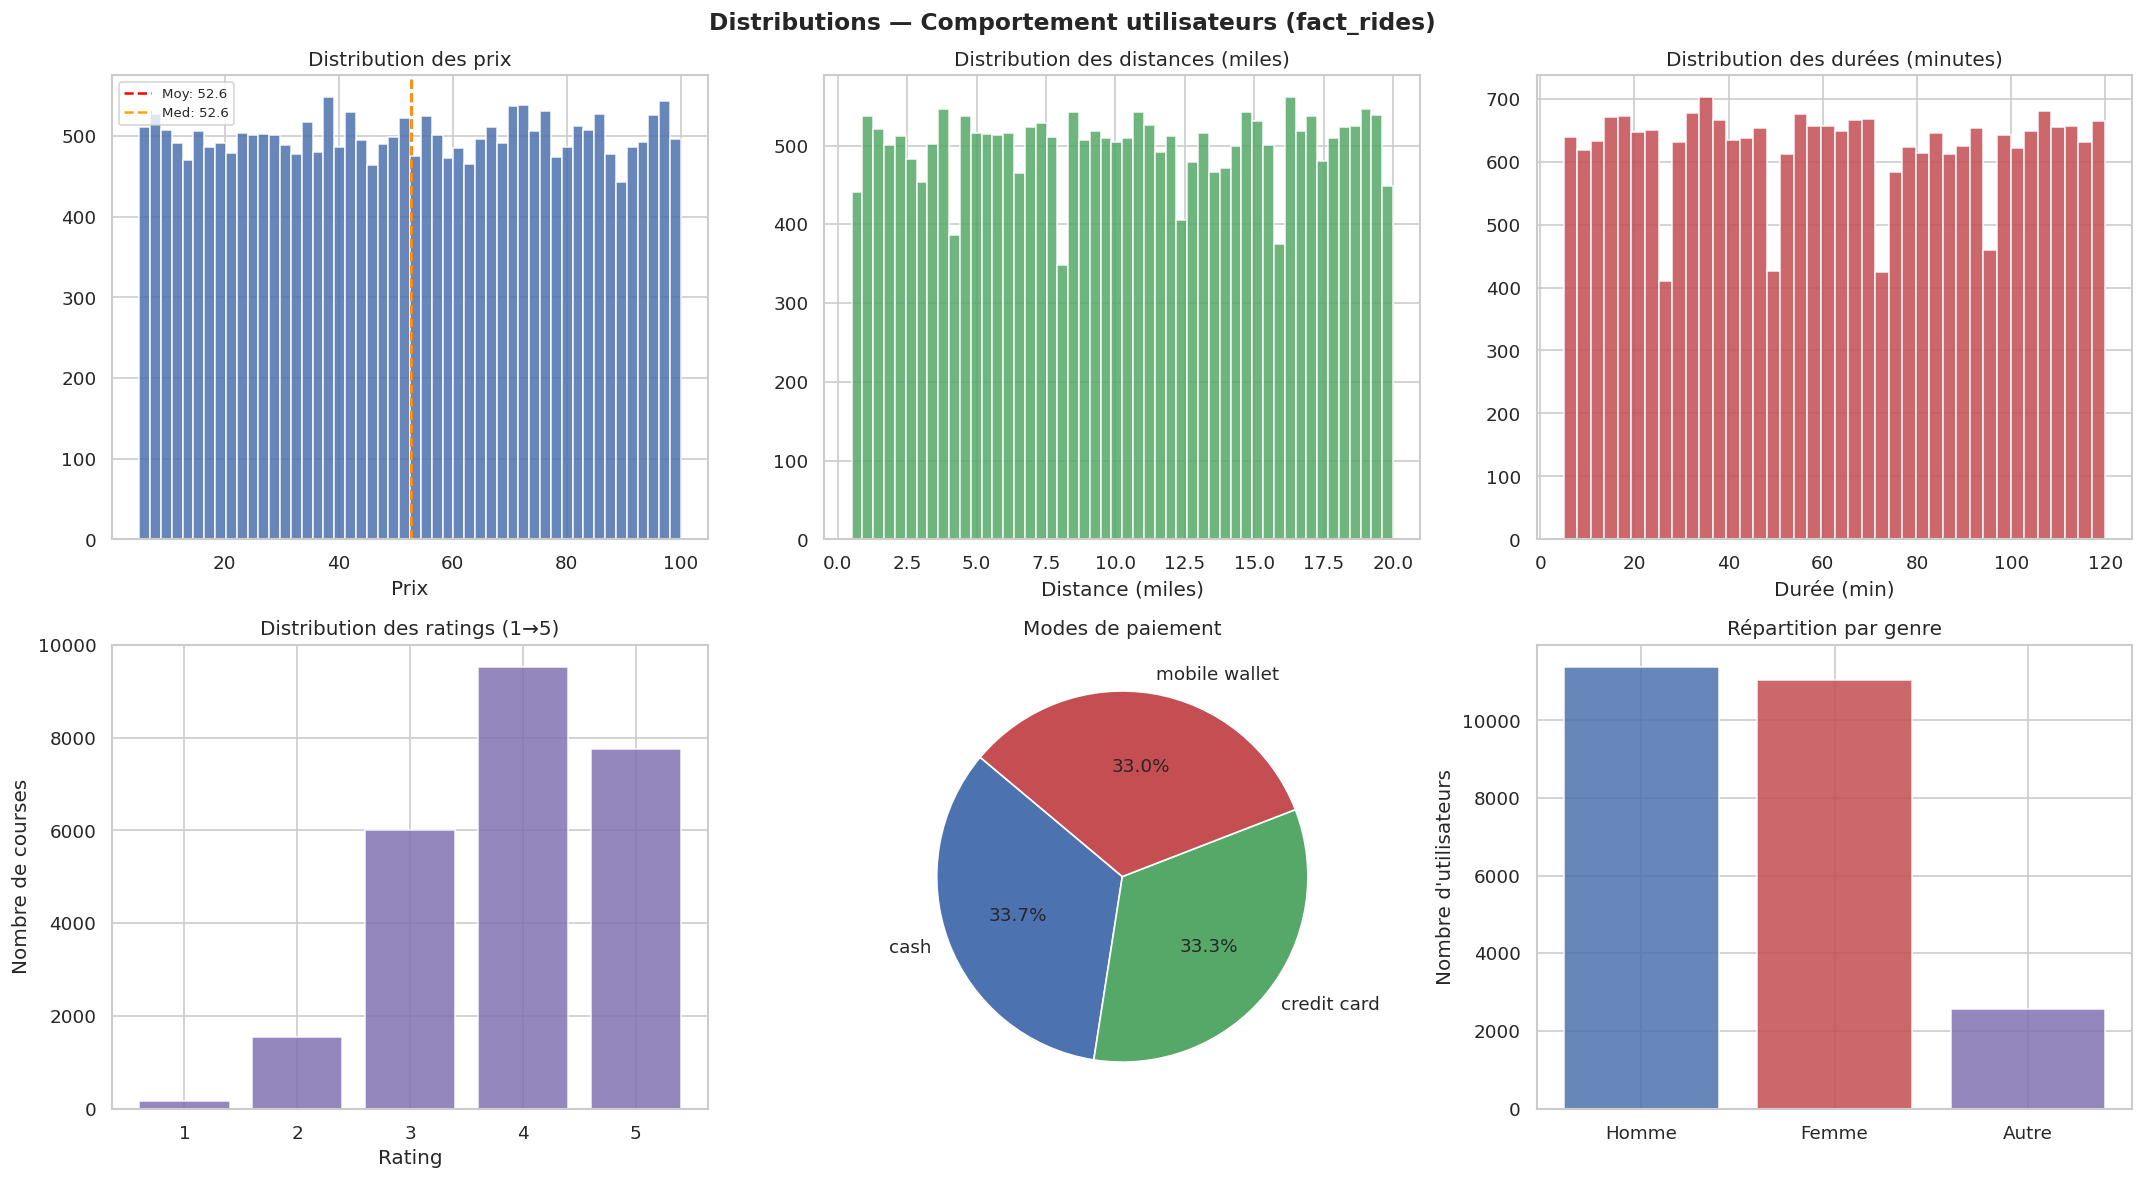


 INSIGHTS — COMPORTEMENT UTILISATEURS
   Prix moyen course     : 52.57
   Distance moyenne      : 10.29 miles
   Durée moyenne         : 62.4 min
   Rating moyen          : 3.93 / 5
   Mode paiement dominant: cash


In [23]:
# Distributions rides
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Distributions — Comportement utilisateurs (fact_rides)",
             fontsize=14, fontweight='bold')

# Fare amount rides
axes[0,0].hist(df_merged['fare_amount'], bins=50, color='#4C72B0', edgecolor='white', alpha=0.85)
axes[0,0].axvline(df_merged['fare_amount'].mean(),   color='red',    linestyle='--', linewidth=1.5, label=f"Moy: {df_merged['fare_amount'].mean():.1f}")
axes[0,0].axvline(df_merged['fare_amount'].median(), color='orange', linestyle='--', linewidth=1.5, label=f"Med: {df_merged['fare_amount'].median():.1f}")
axes[0,0].set_title("Distribution des prix")
axes[0,0].set_xlabel("Prix")
axes[0,0].legend(fontsize=8)

# Distance
axes[0,1].hist(df_merged['ride_distance_miles'], bins=50, color='#55A868', edgecolor='white', alpha=0.85)
axes[0,1].set_title("Distribution des distances (miles)")
axes[0,1].set_xlabel("Distance (miles)")

# Durée
axes[0,2].hist(df_merged['ride_duration_minutes'], bins=40, color='#C44E52', edgecolor='white', alpha=0.85)
axes[0,2].set_title("Distribution des durées (minutes)")
axes[0,2].set_xlabel("Durée (min)")

# Rating
rating_counts = df_merged['rating'].value_counts().sort_index()
axes[1,0].bar(rating_counts.index, rating_counts.values, color='#8172B2', edgecolor='white', alpha=0.85)
axes[1,0].set_title("Distribution des ratings (1→5)")
axes[1,0].set_xlabel("Rating")
axes[1,0].set_ylabel("Nombre de courses")

# Mode de paiement
pm = df_merged['payment_method'].value_counts()
axes[1,1].pie(pm.values, labels=pm.index, autopct='%1.1f%%',
              colors=['#4C72B0','#55A868','#C44E52'], startangle=140)
axes[1,1].set_title("Modes de paiement")

# Genre utilisateurs
gender_map = {'Male':'Homme','Female':'Femme'}
gender_simple = df_merged['gender'].map(gender_map).fillna('Autre')
gc = gender_simple.value_counts()
axes[1,2].bar(gc.index, gc.values, color=['#4C72B0','#C44E52','#8172B2'], edgecolor='white', alpha=0.85)
axes[1,2].set_title("Répartition par genre")
axes[1,2].set_ylabel("Nombre d'utilisateurs")

plt.tight_layout()
plt.savefig('eda_03_distributions_rides.png', bbox_inches='tight')
plt.show()

print("\n INSIGHTS — COMPORTEMENT UTILISATEURS")
print(f"   Prix moyen course     : {df_merged['fare_amount'].mean():.2f}")
print(f"   Distance moyenne      : {df_merged['ride_distance_miles'].mean():.2f} miles")
print(f"   Durée moyenne         : {df_merged['ride_duration_minutes'].mean():.1f} min")
print(f"   Rating moyen          : {df_merged['rating'].mean():.2f} / 5")
print(f"   Mode paiement dominant: {df_merged['payment_method'].value_counts().idxmax()}")

---
## 3.5 Détection des Outliers — Méthode IQR et Z-Score

On utilise deux méthodes complémentaires :
- **IQR (Interquartile Range)** : robuste, basée sur les quartiles
- **Z-Score** : détecte les valeurs à plus de 3 écarts-types de la moyenne


In [24]:
# Calcul IQR sur fare_amount Uber
print("=" * 55)
print("DÉTECTION OUTLIERS — MÉTHODE IQR (uber_clean)")
print("=" * 55)

Q1  = df_uber['fare_amount'].quantile(0.25)
Q3  = df_uber['fare_amount'].quantile(0.75)
IQR = Q3 - Q1
borne_basse = Q1 - 1.5 * IQR
borne_haute = Q3 + 1.5 * IQR

print(f"\n   Q1 (25%)         : ${Q1:.2f}")
print(f"   Q3 (75%)         : ${Q3:.2f}")
print(f"   IQR              : ${IQR:.2f}")
print(f"   Borne basse      : ${borne_basse:.2f}")
print(f"   Borne haute      : ${borne_haute:.2f}")

outliers_iqr = df_uber[(df_uber['fare_amount'] < borne_basse) |
                        (df_uber['fare_amount'] > borne_haute)]
print(f"\n   Outliers détectés (IQR) : {len(outliers_iqr):,} lignes ({len(outliers_iqr)/len(df_uber)*100:.2f}%)")



DÉTECTION OUTLIERS — MÉTHODE IQR (uber_clean)

   Q1 (25%)         : $6.00
   Q3 (75%)         : $12.50
   IQR              : $6.50
   Borne basse      : $-3.75
   Borne haute      : $22.25

   Outliers détectés (IQR) : 17,120 lignes (8.59%)


In [25]:
# Calcul Z-Score
print("\n" + "=" * 55)
print("DÉTECTION OUTLIERS — Z-SCORE (uber_clean)")
print("=" * 55)

z_scores = np.abs(stats.zscore(df_uber['fare_amount']))
outliers_z = df_uber[z_scores > 3]
print(f"\n   Outliers Z > 3 : {len(outliers_z):,} lignes ({len(outliers_z)/len(df_uber)*100:.2f}%)")
print(f"   Prix min outliers Z : ${outliers_z['fare_amount'].min():.2f}")
print(f"   Prix max outliers Z : ${outliers_z['fare_amount'].max():.2f}")



DÉTECTION OUTLIERS — Z-SCORE (uber_clean)

   Outliers Z > 3 : 5,435 lignes (2.73%)
   Prix min outliers Z : $41.16
   Prix max outliers Z : $499.00



DÉTECTION OUTLIERS — MÉTHODE IQR (rides_merged)
   IQR rides        : 47.50
   Borne basse      : -42.48
   Borne haute      : 147.53
   Outliers IQR     : 0 lignes (0.00%)


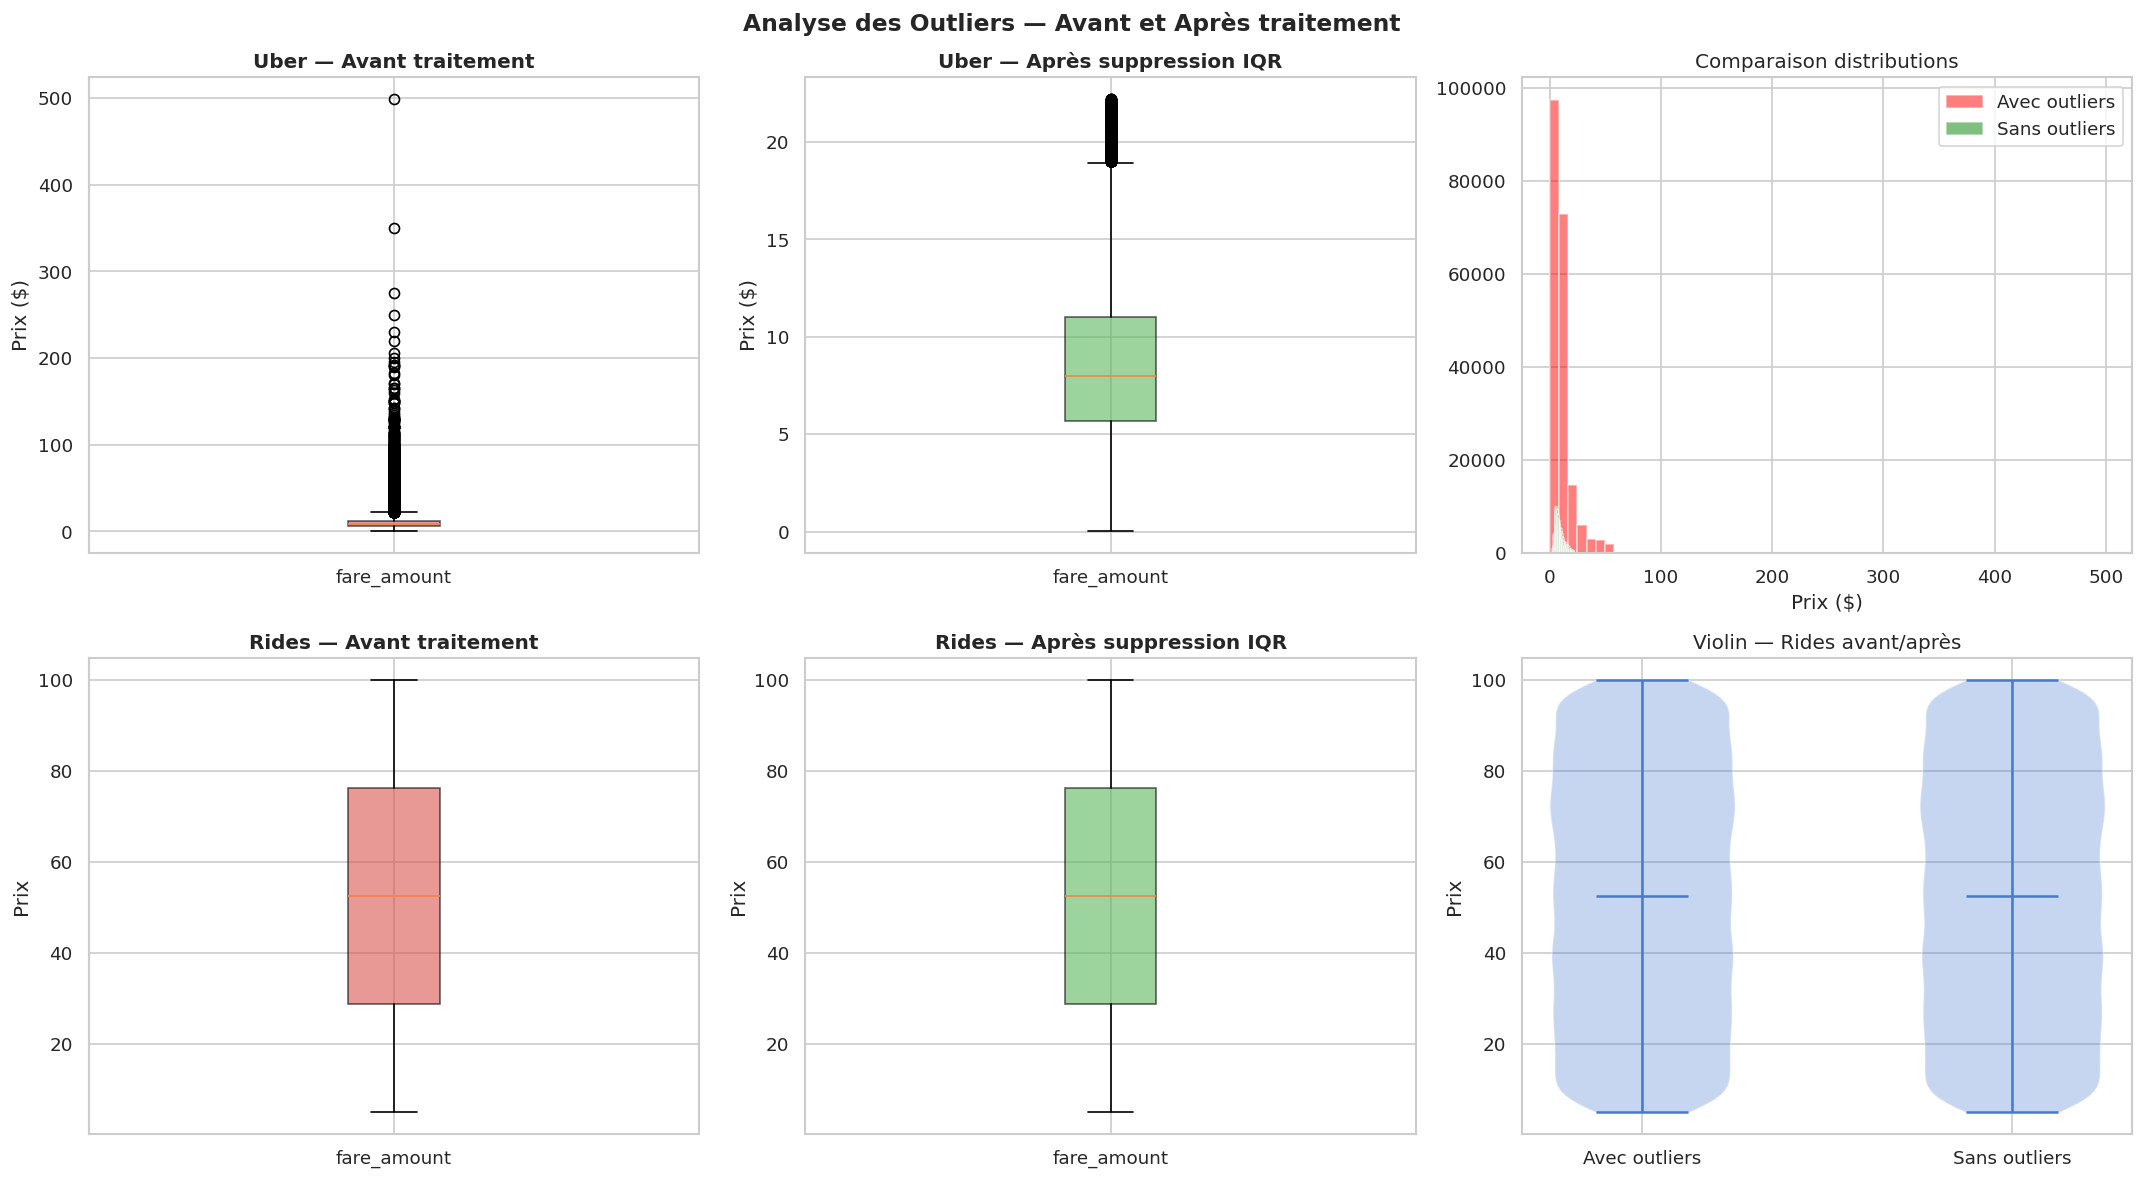


 DÉCISION FINALE — OUTLIERS
   Uber  : 199,256 → 182,136 lignes après suppression IQR
   Rides : 25,000 → 25,000 lignes après suppression IQR
   → Datasets finaux utilisés pour la suite de l'analyse


In [27]:
# Visualisation outliers
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Analyse des Outliers — Avant et Après traitement",
             fontsize=14, fontweight='bold')

# Boxplot avant — Uber
axes[0,0].boxplot(df_uber['fare_amount'], vert=True, patch_artist=True,
                  boxprops=dict(facecolor='#d9534f', alpha=0.6))
axes[0,0].set_title("Uber — Avant traitement", fontweight='bold')
axes[0,0].set_ylabel("Prix ($)")
axes[0,0].set_xticks([1])
axes[0,0].set_xticklabels(['fare_amount'])

# Dataset sans outliers IQR
df_uber_no_out = df_uber[(df_uber['fare_amount'] >= borne_basse) &
                          (df_uber['fare_amount'] <= borne_haute)]

# Boxplot après — Uber
axes[0,1].boxplot(df_uber_no_out['fare_amount'], vert=True, patch_artist=True,
                  boxprops=dict(facecolor='#5cb85c', alpha=0.6))
axes[0,1].set_title("Uber — Après suppression IQR", fontweight='bold')
axes[0,1].set_ylabel("Prix ($)")
axes[0,1].set_xticks([1])
axes[0,1].set_xticklabels(['fare_amount'])

# Comparaison histogramme avant/après
axes[0,2].hist(df_uber['fare_amount'],        bins=60, alpha=0.5, color='red',   label='Avec outliers')
axes[0,2].hist(df_uber_no_out['fare_amount'], bins=60, alpha=0.5, color='green', label='Sans outliers')
axes[0,2].set_title("Comparaison distributions")
axes[0,2].set_xlabel("Prix ($)")
axes[0,2].legend()

# Même analyse sur rides
print("\n" + "=" * 55)
print("DÉTECTION OUTLIERS — MÉTHODE IQR (rides_merged)")
print("=" * 55)

Q1_r  = df_merged['fare_amount'].quantile(0.25)
Q3_r  = df_merged['fare_amount'].quantile(0.75)
IQR_r = Q3_r - Q1_r
borne_basse_r = Q1_r - 1.5 * IQR_r
borne_haute_r = Q3_r + 1.5 * IQR_r

print(f"   IQR rides        : {IQR_r:.2f}")
print(f"   Borne basse      : {borne_basse_r:.2f}")
print(f"   Borne haute      : {borne_haute_r:.2f}")

outliers_r = df_merged[(df_merged['fare_amount'] < borne_basse_r) |
                        (df_merged['fare_amount'] > borne_haute_r)]
print(f"   Outliers IQR     : {len(outliers_r):,} lignes ({len(outliers_r)/len(df_merged)*100:.2f}%)")

df_merged_no_out = df_merged[(df_merged['fare_amount'] >= borne_basse_r) &
                              (df_merged['fare_amount'] <= borne_haute_r)]

# Boxplot rides avant
axes[1,0].boxplot(df_merged['fare_amount'], vert=True, patch_artist=True,
                  boxprops=dict(facecolor='#d9534f', alpha=0.6))
axes[1,0].set_title("Rides — Avant traitement", fontweight='bold')
axes[1,0].set_ylabel("Prix")
axes[1,0].set_xticks([1])
axes[1,0].set_xticklabels(['fare_amount'])

# Boxplot rides après
axes[1,1].boxplot(df_merged_no_out['fare_amount'], vert=True, patch_artist=True,
                  boxprops=dict(facecolor='#5cb85c', alpha=0.6))
axes[1,1].set_title("Rides — Après suppression IQR", fontweight='bold')
axes[1,1].set_ylabel("Prix")
axes[1,1].set_xticks([1])
axes[1,1].set_xticklabels(['fare_amount'])

# Violin plot comparatif
data_violin = [df_merged['fare_amount'].values, df_merged_no_out['fare_amount'].values]
axes[1,2].violinplot(data_violin, showmedians=True)
axes[1,2].set_xticks([1, 2])
axes[1,2].set_xticklabels(['Avec outliers', 'Sans outliers'])
axes[1,2].set_title("Violin — Rides avant/après")
axes[1,2].set_ylabel("Prix")

plt.tight_layout()
plt.savefig('eda_04_outliers.png', bbox_inches='tight')
plt.show()

print("\n DÉCISION FINALE — OUTLIERS")
print(f"   Uber  : {len(df_uber):,} → {len(df_uber_no_out):,} lignes après suppression IQR")
print(f"   Rides : {len(df_merged):,} → {len(df_merged_no_out):,} lignes après suppression IQR")
print(f"   → Datasets finaux utilisés pour la suite de l'analyse")

# Mise à jour des datasets pour la suite
df_uber_final   = df_uber_no_out.copy()
df_merged_final = df_merged_no_out.copy()


---
## 3.6 Analyse des Corrélations

La heatmap de corrélation révèle les relations linéaires entre
toutes les variables numériques. Un coefficient proche de 1 ou -1
indique une forte relation.

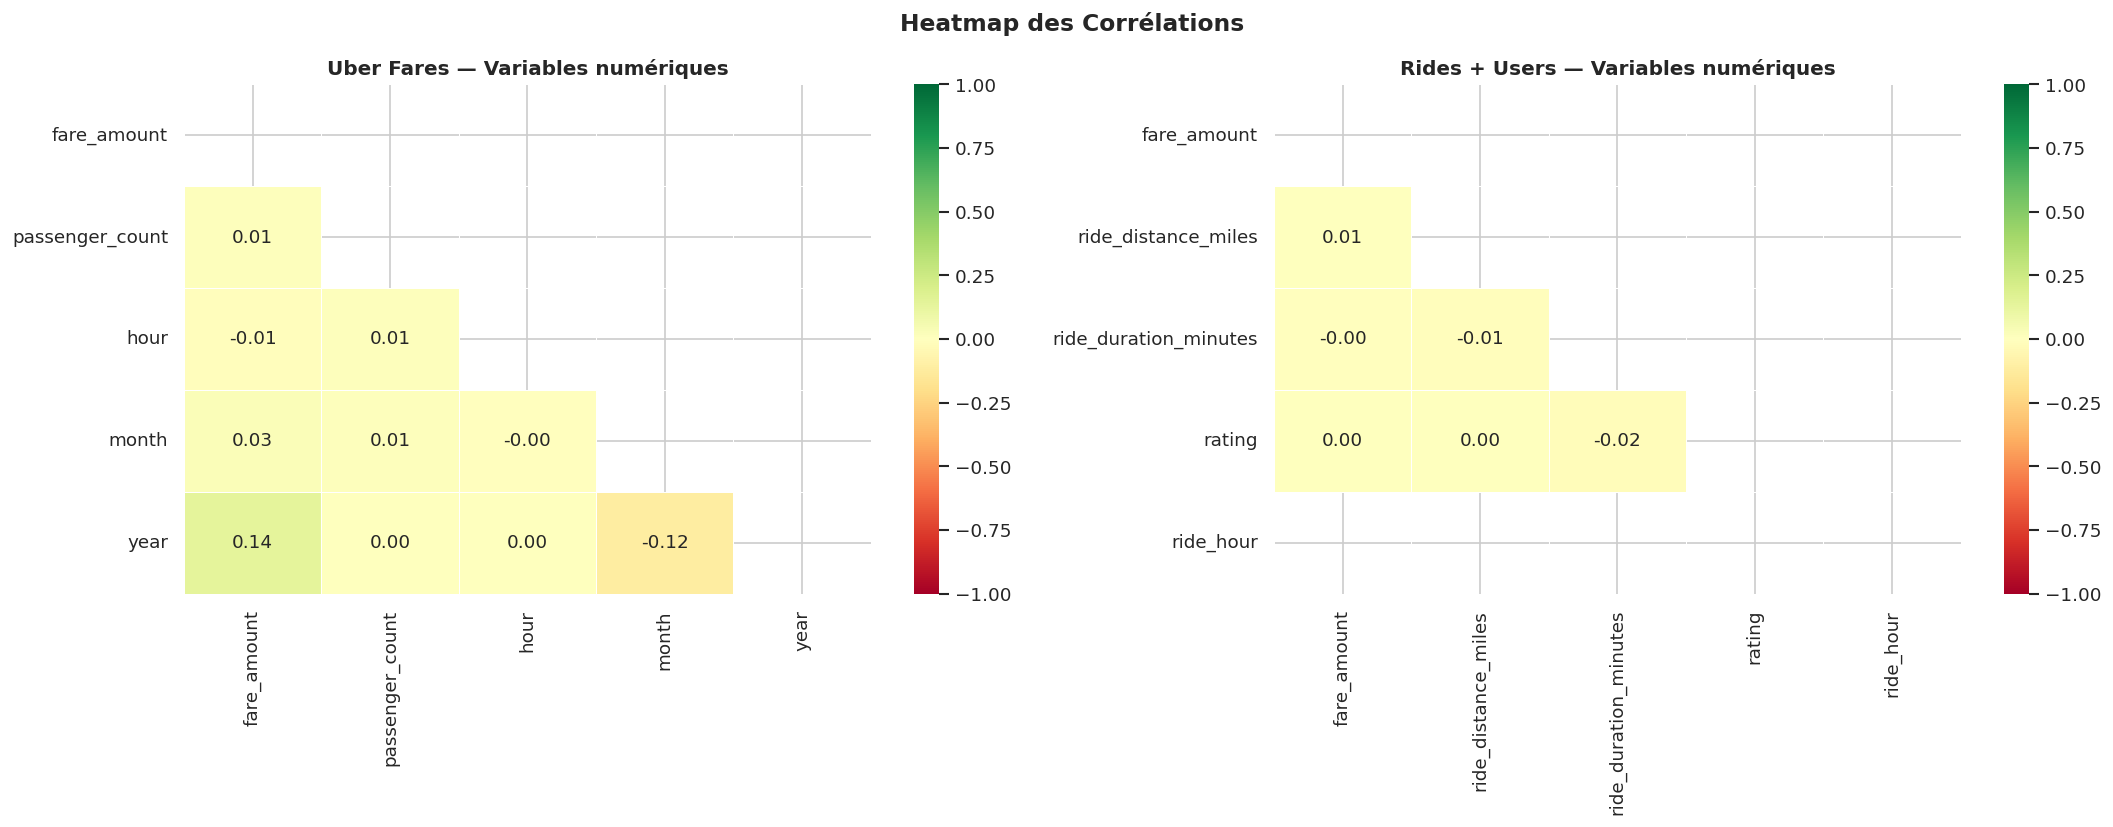

 INSIGHTS — CORRÉLATIONS

   Uber Fares :
   fare_amount ↔ year                 : +0.136

   Rides :


In [28]:
# Heatmap corrélation Uber
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Heatmap des Corrélations", fontsize=14, fontweight='bold')

# Uber : variables numériques
uber_num = df_uber_final[['fare_amount', 'passenger_count', 'hour', 'month', 'year']].copy()
corr_uber = uber_num.corr()

mask_uber = np.triu(np.ones_like(corr_uber, dtype=bool))
sns.heatmap(corr_uber, mask=mask_uber, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white', ax=axes[0],
            annot_kws={'size': 11})
axes[0].set_title("Uber Fares — Variables numériques", fontweight='bold')

# Rides : variables numériques
rides_num = df_merged_final[['fare_amount', 'ride_distance_miles',
                              'ride_duration_minutes', 'rating', 'ride_hour']].copy()
corr_rides = rides_num.corr()

mask_rides = np.triu(np.ones_like(corr_rides, dtype=bool))
sns.heatmap(corr_rides, mask=mask_rides, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white', ax=axes[1],
            annot_kws={'size': 11})
axes[1].set_title("Rides + Users — Variables numériques", fontweight='bold')

plt.tight_layout()
plt.savefig('eda_05_heatmap_correlations.png', bbox_inches='tight')
plt.show()

print(" INSIGHTS — CORRÉLATIONS")
print("\n   Uber Fares :")
for col in corr_uber.columns:
    corr_fare = corr_uber['fare_amount'][col]
    if col != 'fare_amount' and abs(corr_fare) > 0.05:
        print(f"   fare_amount ↔ {col:<20} : {corr_fare:+.3f}")

print("\n   Rides :")
for col in corr_rides.columns:
    corr_fare = corr_rides['fare_amount'][col]
    if col != 'fare_amount' and abs(corr_fare) > 0.05:
        print(f"   fare_amount ↔ {col:<25} : {corr_fare:+.3f}")



---
## 3.7 Scatter Matrix — Relations entre variables clés

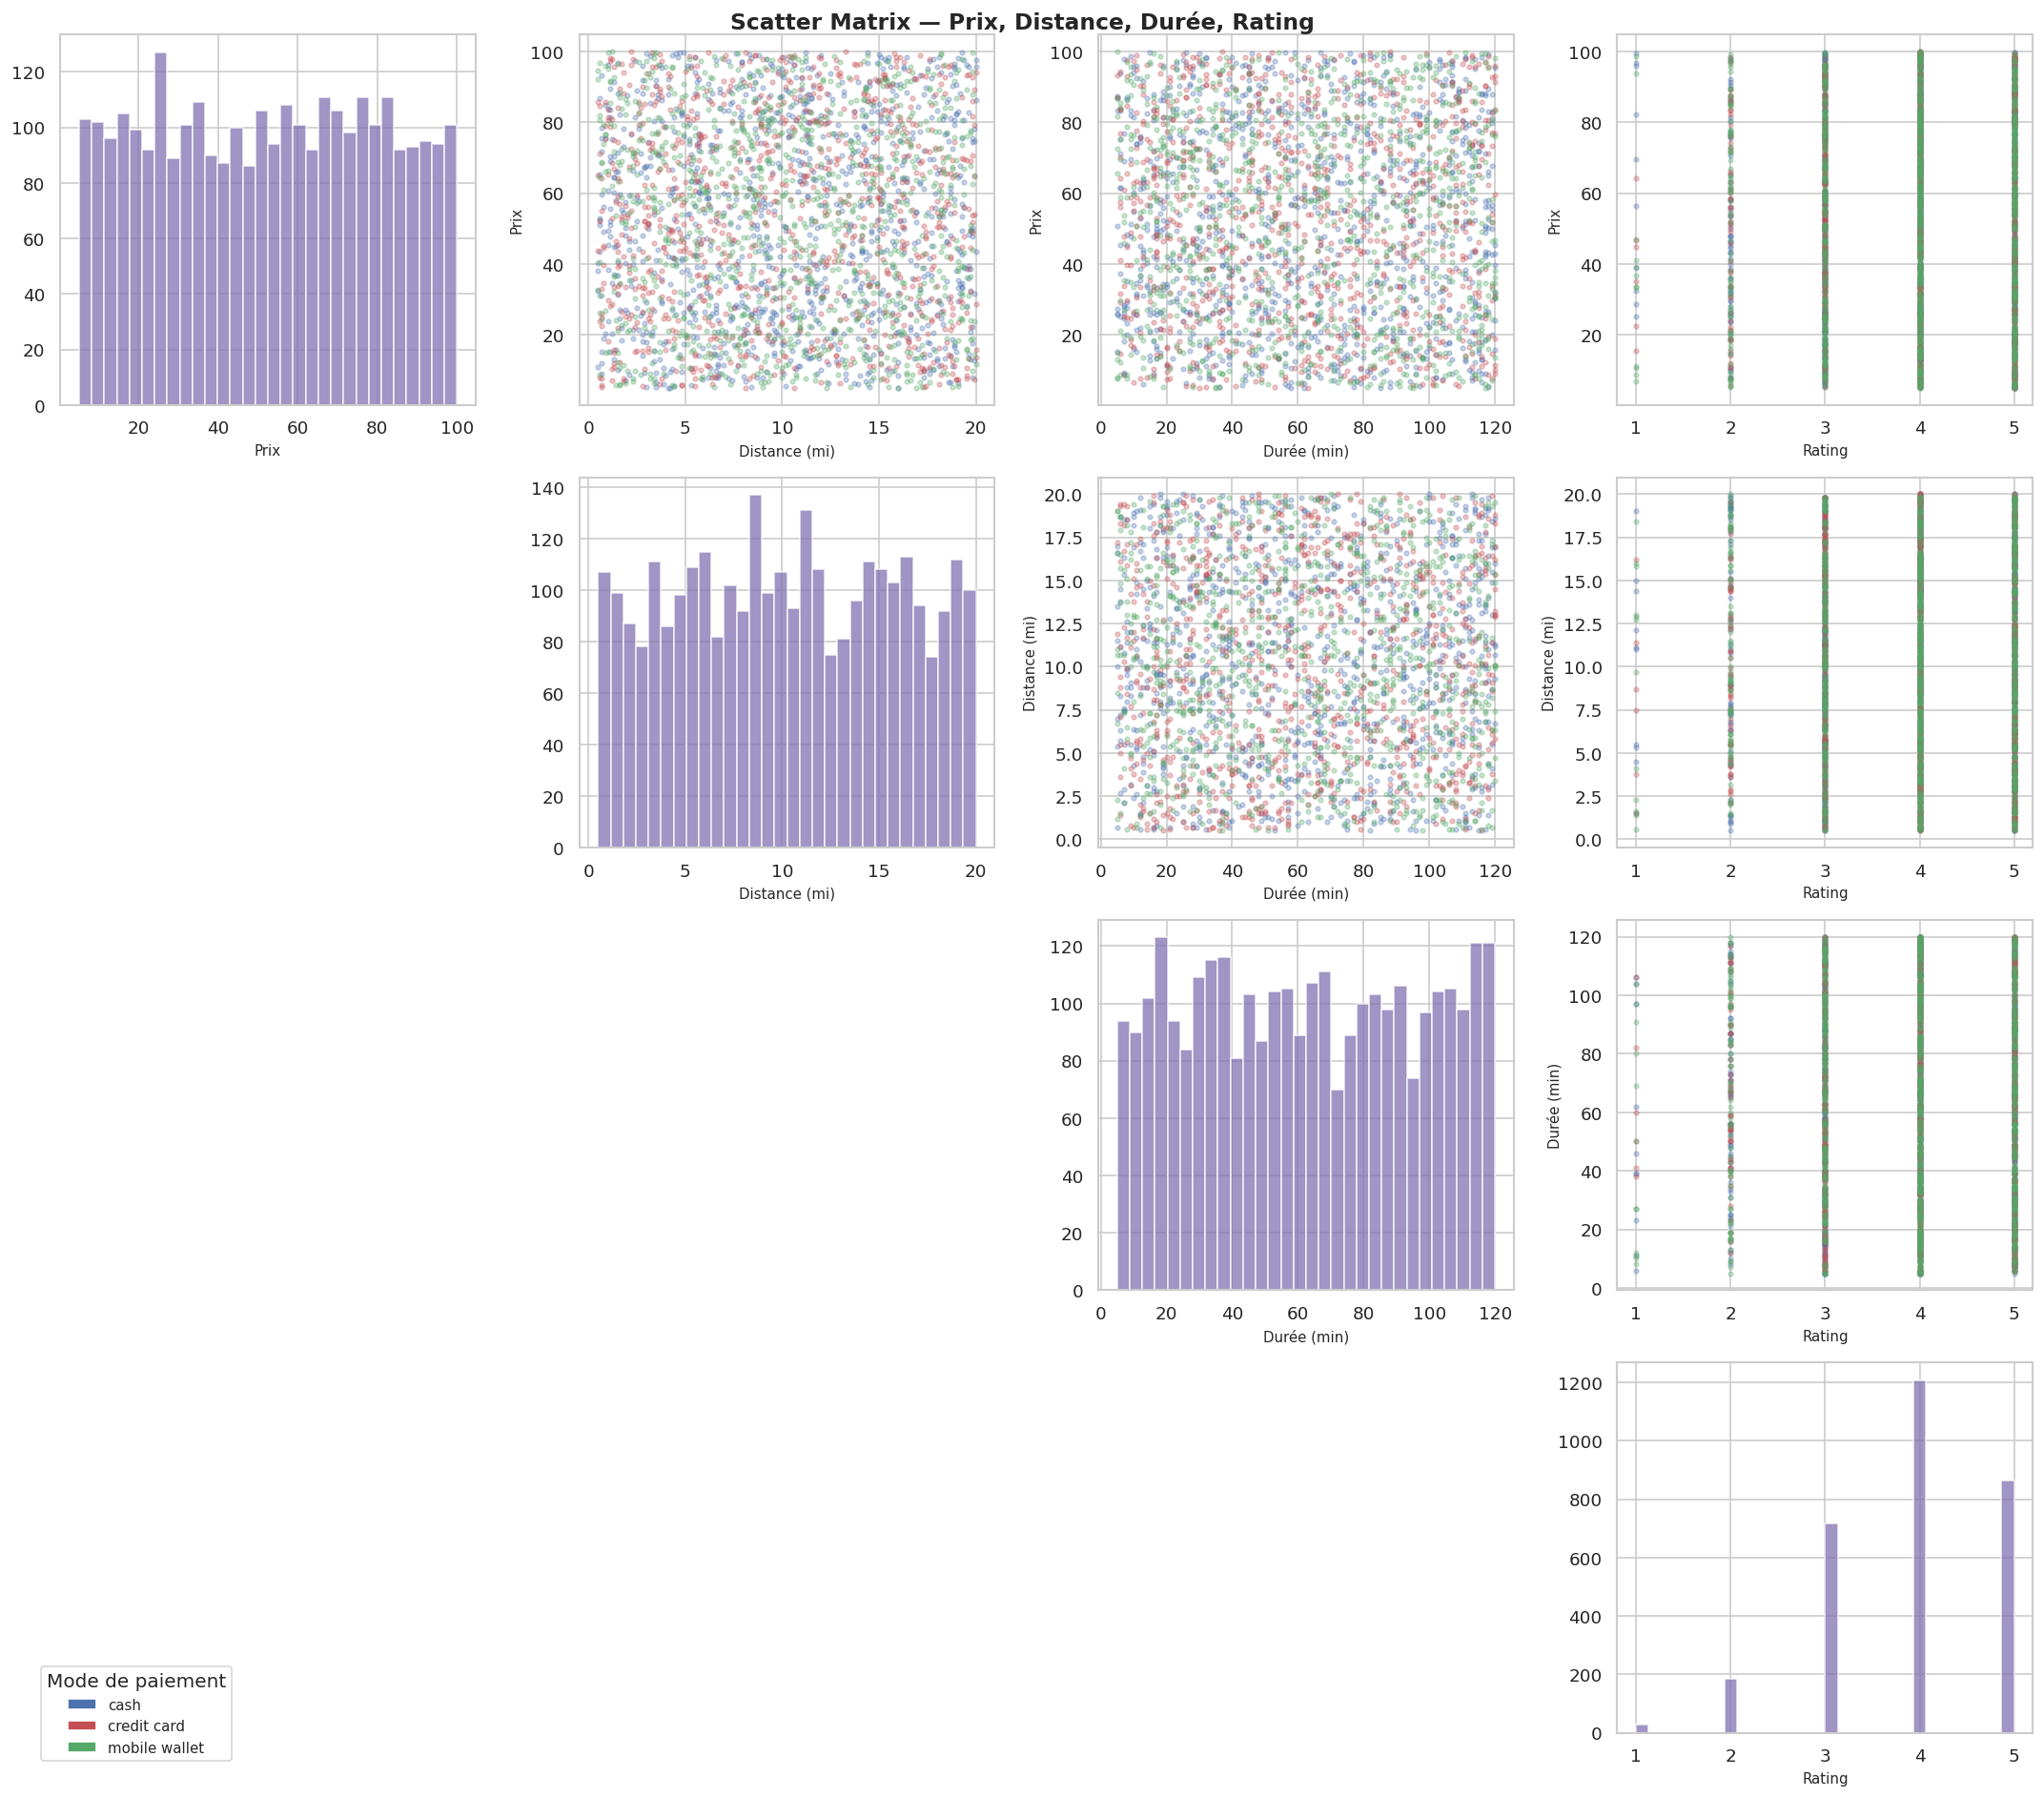

In [30]:
# Scatter matrix Rides
fig, axes = plt.subplots(4, 4, figsize=(18, 16))
fig.suptitle("Scatter Matrix — Prix, Distance, Durée, Rating",
             fontsize=14, fontweight='bold')

vars_scatter = ['fare_amount', 'ride_distance_miles', 'ride_duration_minutes', 'rating']
labels = ['Prix', 'Distance (mi)', 'Durée (min)', 'Rating']

colors_pm = {
    'cash': '#4C72B0',
    'credit card': '#C44E52',
    'mobile wallet': '#55A868'
}

sample = df_merged_final.sample(n=min(3000, len(df_merged_final)), random_state=42)

for i, (var_y, lab_y) in enumerate(zip(vars_scatter, labels)):
    for j, (var_x, lab_x) in enumerate(zip(vars_scatter, labels)):

        if i == j:
            axes[i][j].hist(sample[var_y], bins=30, color='#8172B2', alpha=0.75, edgecolor='white')
            axes[i][j].set_xlabel(lab_x, fontsize=9)

        elif i < j:
            for pm, col in colors_pm.items():
                mask = sample['payment_method'] == pm
                axes[i][j].scatter(
                    sample.loc[mask, var_x],
                    sample.loc[mask, var_y],
                    alpha=0.3,
                    s=8,
                    color=col,
                    label=pm
                )

            axes[i][j].set_xlabel(lab_x, fontsize=9)
            axes[i][j].set_ylabel(lab_y, fontsize=9)

        else:
            axes[i][j].axis('off')

from matplotlib.patches import Patch

legend_elements = [Patch(facecolor=c, label=pm) for pm, c in colors_pm.items()]
fig.legend(
    handles=legend_elements,
    title='Mode de paiement',
    loc='lower left',
    bbox_to_anchor=(0.02, 0.02),
    fontsize=9
)

plt.tight_layout()
plt.savefig('eda_06_scatter_matrix.png', bbox_inches='tight')
plt.show()

---
## 3.8 Tests Statistiques

### Pourquoi faire des tests ?
Les visualisations montrent des patterns, mais les tests statistiques
confirment si ces différences sont **réelles** ou dues au hasard.

- **t-test** : comparer deux moyennes (ex: prix heure de pointe vs heure creuse)
- **ANOVA** : comparer plusieurs groupes (ex: prix selon le jour de la semaine)
- **Chi-deux** : tester l'indépendance entre deux variables catégorielles


In [31]:
# %% — TEST 1 : t-test — Prix heure de pointe vs heure creuse (Uber)
print("=" * 55)
print("TEST 1 — t-test : Prix en heure de pointe vs creuse")
print("Dataset : uber_clean")
print("=" * 55)

# Définition des heures de pointe (contexte Maroc : matin 7-9h, soir 17-19h)
heures_pointe  = [7, 8, 9, 17, 18, 19]
prix_pointe    = df_uber_final[df_uber_final['hour'].isin(heures_pointe)]['fare_amount']
prix_hors_pte  = df_uber_final[~df_uber_final['hour'].isin(heures_pointe)]['fare_amount']

t_stat, p_val = stats.ttest_ind(prix_pointe, prix_hors_pte)

print(f"\n   Hypothèse nulle H0  : prix_pointe = prix_hors_pointe")
print(f"   Hypothèse alt. H1   : prix_pointe ≠ prix_hors_pointe")
print(f"\n   Moyenne heure pointe  : ${prix_pointe.mean():.2f} ({len(prix_pointe):,} courses)")
print(f"   Moyenne heure creuse  : ${prix_hors_pte.mean():.2f} ({len(prix_hors_pte):,} courses)")
print(f"\n   t-statistique         : {t_stat:.4f}")
print(f"   p-value               : {p_val:.4e}")

if p_val < 0.05:
    print(f"\n   RÉSULTAT : p < 0.05 → On rejette H0")
    print(f"      La différence de prix est statistiquement significative")
else:
    print(f"\n   RÉSULTAT : p > 0.05 → On ne rejette pas H0")
    print(f"      La différence n'est pas statistiquement significative")



TEST 1 — t-test : Prix en heure de pointe vs creuse
Dataset : uber_clean

   Hypothèse nulle H0  : prix_pointe = prix_hors_pointe
   Hypothèse alt. H1   : prix_pointe ≠ prix_hors_pointe

   Moyenne heure pointe  : $8.83 (55,382 courses)
   Moyenne heure creuse  : $8.99 (126,754 courses)

   t-statistique         : -7.6684
   p-value               : 1.7505e-14

   RÉSULTAT : p < 0.05 → On rejette H0
      La différence de prix est statistiquement significative


In [32]:
# TEST 2 : ANOVA — Prix selon le jour de la semaine (Uber)
print("\n" + "=" * 55)
print("TEST 2 — ANOVA : Prix selon le jour de la semaine")
print("Dataset : uber_clean")
print("=" * 55)

groupes_jours = [df_uber_final[df_uber_final['day_of_week'] == j]['fare_amount']
                 for j in ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']]

f_stat, p_anova = stats.f_oneway(*groupes_jours)

print(f"\n   H0 : le prix moyen est identique tous les jours")
print(f"   H1 : au moins un jour a un prix moyen différent")
print(f"\n   Prix moyen par jour :")
for jour, grp in zip(['Lun','Mar','Mer','Jeu','Ven','Sam','Dim'], groupes_jours):
    print(f"     {jour} : ${grp.mean():.2f}")
print(f"\n   F-statistique : {f_stat:.4f}")
print(f"   p-value       : {p_anova:.4e}")
if p_anova < 0.05:
    print(f"   Différence significative entre les jours (p < 0.05)")
else:
    print(f"   Pas de différence significative entre les jours")



TEST 2 — ANOVA : Prix selon le jour de la semaine
Dataset : uber_clean

   H0 : le prix moyen est identique tous les jours
   H1 : au moins un jour a un prix moyen différent

   Prix moyen par jour :
     Lun : $8.67
     Mar : $8.86
     Mer : $8.98
     Jeu : $9.03
     Ven : $9.04
     Sam : $9.03
     Dim : $8.93

   F-statistique : 25.2008
   p-value       : 4.4329e-30
   Différence significative entre les jours (p < 0.05)


In [33]:
# TEST 3 : Chi-deux — Mode de paiement vs Rating (Rides)
print("\n" + "=" * 55)
print("TEST 3 — Chi-deux : Mode de paiement ↔ Rating")
print("Dataset : rides_users_merged")
print("=" * 55)

df_merged_final['rating_int'] = df_merged_final['rating'].astype(int)
tableau_contingence = pd.crosstab(df_merged_final['payment_method'],
                                   df_merged_final['rating_int'])

print(f"\n   Tableau de contingence :")
print(tableau_contingence)

chi2, p_chi2, dof, expected = stats.chi2_contingency(tableau_contingence)

print(f"\n   H0 : le mode de paiement est indépendant du rating")
print(f"   H1 : il existe une relation entre paiement et rating")
print(f"\n   Chi2-statistique : {chi2:.4f}")
print(f"   Degrés de liberté: {dof}")
print(f"   p-value          : {p_chi2:.4e}")
if p_chi2 < 0.05:
    print(f"  Relation significative entre mode de paiement et rating")
else:
    print(f"  Pas de relation significative (variables indépendantes)")



TEST 3 — Chi-deux : Mode de paiement ↔ Rating
Dataset : rides_users_merged

   Tableau de contingence :
rating_int       1    2     3     4     5
payment_method                           
cash            60  505  2012  3225  2611
credit card     49  530  2034  3125  2596
mobile wallet   51  504  1971  3183  2544

   H0 : le mode de paiement est indépendant du rating
   H1 : il existe une relation entre paiement et rating

   Chi2-statistique : 4.1560
   Degrés de liberté: 8
   p-value          : 8.4278e-01
  Pas de relation significative (variables indépendantes)


In [34]:
# TEST 4 : Mann-Whitney — Rating cash vs carte (non-paramétrique)
print("\n" + "=" * 55)
print("TEST 4 — Mann-Whitney : Rating cash vs carte")
print("Dataset : rides_users_merged")
print("=" * 55)

rating_cash  = df_merged_final[df_merged_final['payment_method'] == 'cash']['rating']
rating_carte = df_merged_final[df_merged_final['payment_method'] == 'credit card']['rating']

u_stat, p_mw = stats.mannwhitneyu(rating_cash, rating_carte, alternative='two-sided')

print(f"\n   H0 : rating identique pour cash et carte")
print(f"   Rating moyen cash   : {rating_cash.mean():.3f}")
print(f"   Rating moyen carte  : {rating_carte.mean():.3f}")
print(f"\n   U-statistique : {u_stat:.1f}")
print(f"   p-value       : {p_mw:.4e}")
if p_mw < 0.05:
    print(f"  Différence de rating significative entre cash et carte")
else:
    print(f"  Pas de différence significative de rating")




TEST 4 — Mann-Whitney : Rating cash vs carte
Dataset : rides_users_merged

   H0 : rating identique pour cash et carte
   Rating moyen cash   : 3.930
   Rating moyen carte  : 3.923

   U-statistique : 35208175.5
   p-value       : 6.1061e-01
  Pas de différence significative de rating


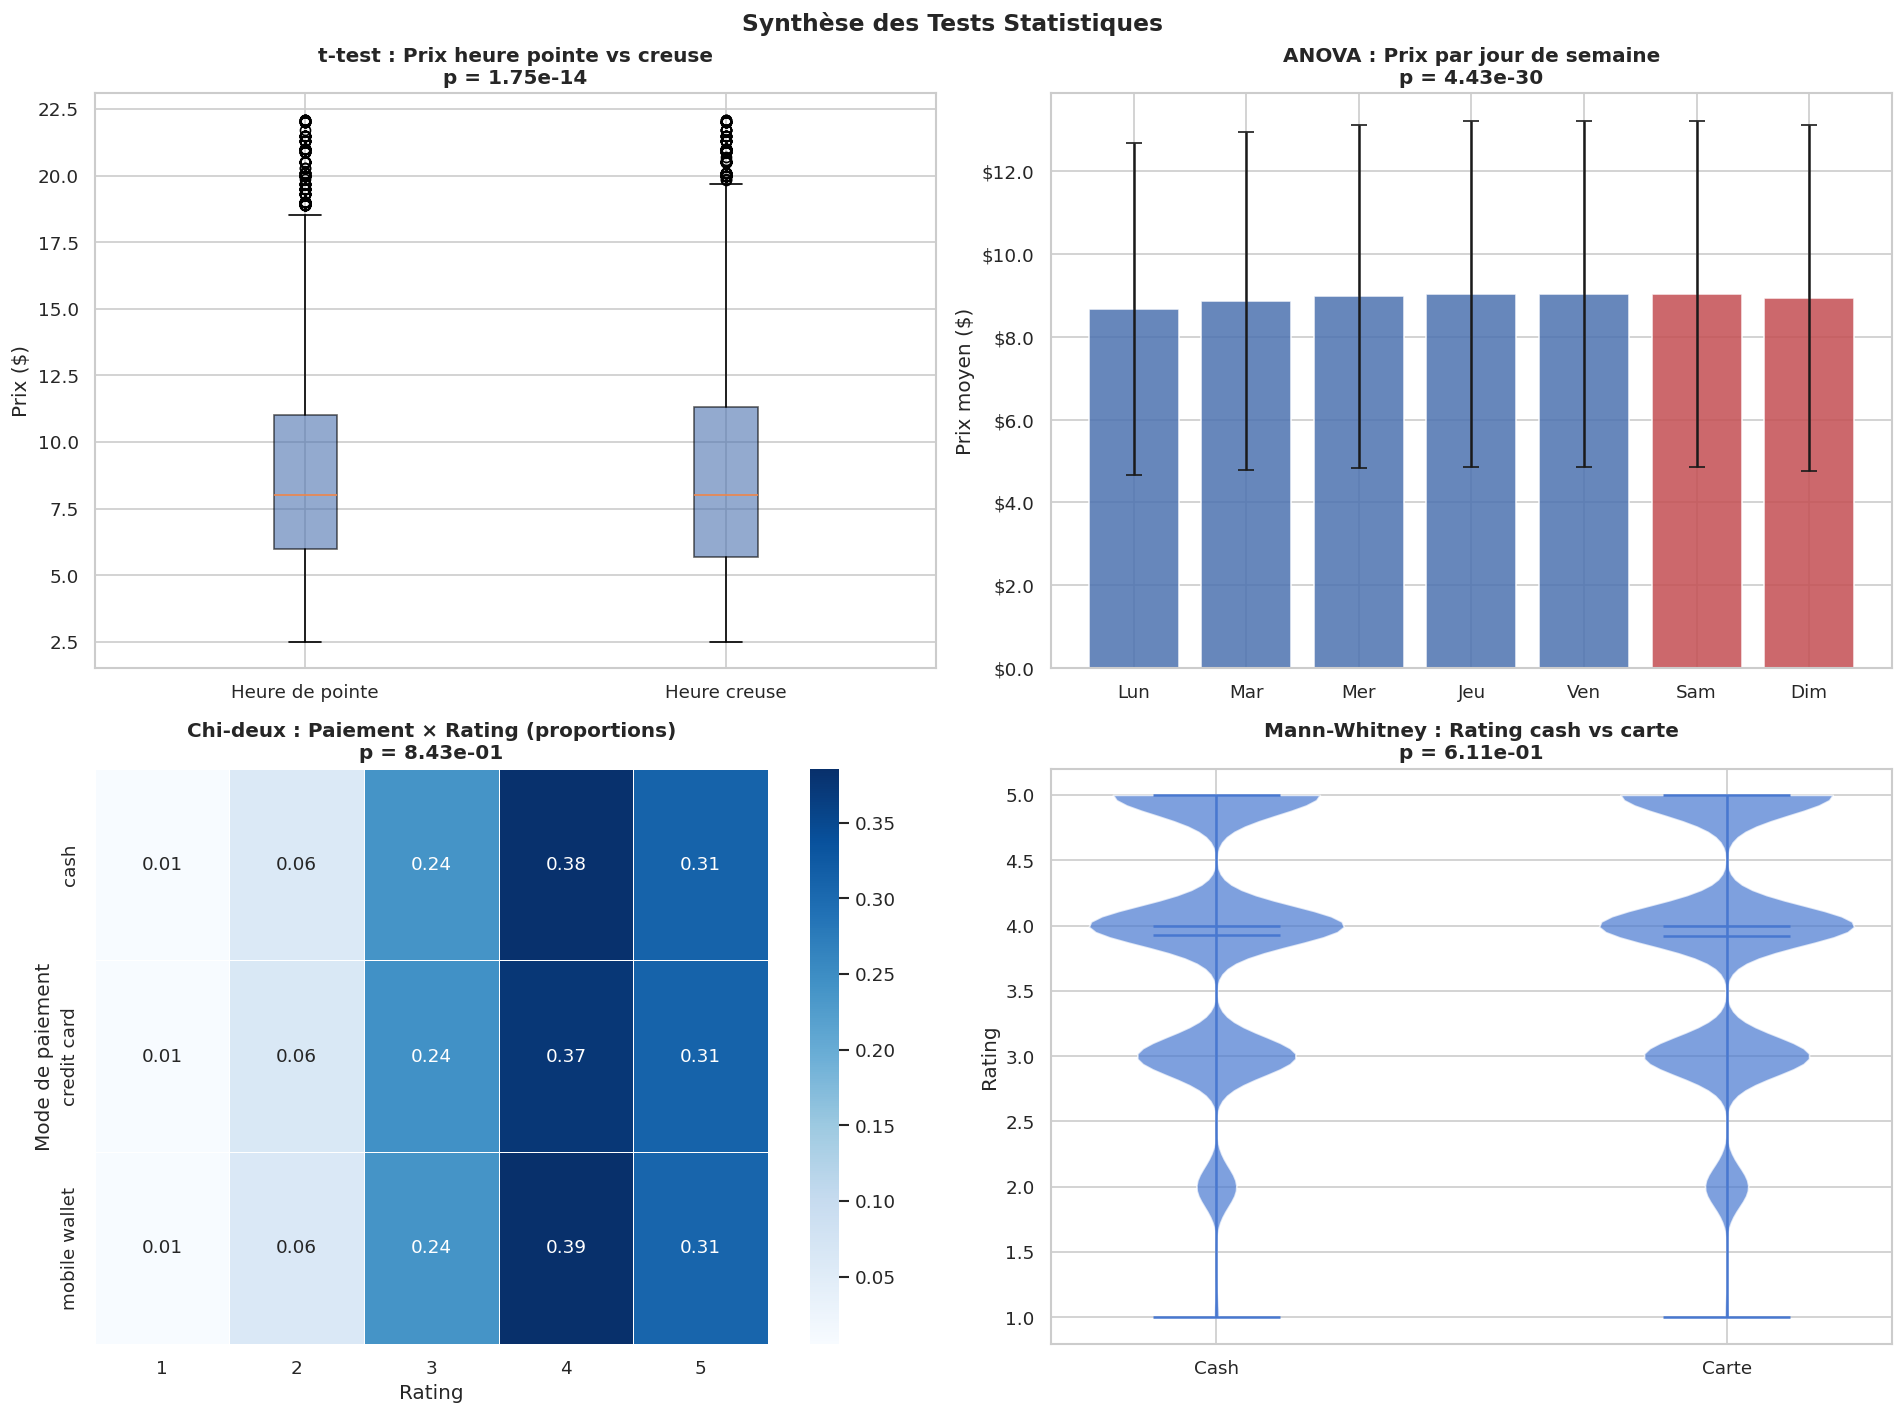


SYNTHÈSE DES 4 TESTS
   t-test prix pointe/creuse                p = 1.75e-14 → Significatif
   ANOVA prix par jour                      p = 4.43e-30 → Significatif
   Chi-deux paiement × rating               p = 8.43e-01 → Non significatif
   Mann-Whitney rating cash/carte           p = 6.11e-01 → Non significatif


In [35]:
# Visualisation des 4 tests
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Synthèse des Tests Statistiques", fontsize=14, fontweight='bold')

# Test 1 : Boxplot pointe vs creuse
data_test1 = [
    prix_pointe.sample(5000, random_state=42),
    prix_hors_pte.sample(5000, random_state=42)
]

axes[0,0].boxplot(
    data_test1,
    labels=['Heure de pointe', 'Heure creuse'],
    patch_artist=True,
    boxprops=dict(facecolor='#4C72B0', alpha=0.6)
)

axes[0,0].set_title(
    f"t-test : Prix heure pointe vs creuse\np = {p_val:.2e}",
    fontweight='bold'
)

axes[0,0].set_ylabel("Prix ($)")

# Test 2 : Bar ANOVA
jours = ['Lun','Mar','Mer','Jeu','Ven','Sam','Dim']
moyennes = [g.mean() for g in groupes_jours]
std_devs = [g.std() for g in groupes_jours]

couleurs = [
    '#C44E52' if j in ['Sam','Dim'] else '#4C72B0'
    for j in jours
]

axes[0,1].bar(
    jours,
    moyennes,
    yerr=std_devs,
    capsize=5,
    color=couleurs,
    edgecolor='white',
    alpha=0.85
)

axes[0,1].set_title(
    f"ANOVA : Prix par jour de semaine\np = {p_anova:.2e}",
    fontweight='bold'
)

axes[0,1].set_ylabel("Prix moyen ($)")
axes[0,1].yaxis.set_major_formatter(
    ticker.FormatStrFormatter('$%.1f')
)

# Test 3 : Heatmap chi-deux normalisée
tableau_norm = tableau_contingence.div(
    tableau_contingence.sum(axis=1),
    axis=0
)

sns.heatmap(
    tableau_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    linewidths=0.5,
    ax=axes[1,0]
)

axes[1,0].set_title(
    f"Chi-deux : Paiement × Rating (proportions)\np = {p_chi2:.2e}",
    fontweight='bold'
)

axes[1,0].set_xlabel("Rating")
axes[1,0].set_ylabel("Mode de paiement")

# Test 4 : Violin Mann-Whitney
data_violin = [rating_cash.values, rating_carte.values]

vp = axes[1,1].violinplot(
    data_violin,
    showmedians=True,
    showmeans=True
)

for body in vp['bodies']:
    body.set_alpha(0.7)

axes[1,1].set_xticks([1, 2])
axes[1,1].set_xticklabels(['Cash', 'Carte'])

axes[1,1].set_title(
    f"Mann-Whitney : Rating cash vs carte\np = {p_mw:.2e}",
    fontweight='bold'
)

axes[1,1].set_ylabel("Rating")

plt.tight_layout()
plt.savefig('eda_07_tests_statistiques.png', bbox_inches='tight')
plt.show()

print("\n" + "=" * 55)
print("SYNTHÈSE DES 4 TESTS")
print("=" * 55)

resultats = [
    ("t-test prix pointe/creuse",      p_val,   p_val < 0.05),
    ("ANOVA prix par jour",            p_anova, p_anova < 0.05),
    ("Chi-deux paiement × rating",     p_chi2,  p_chi2 < 0.05),
    ("Mann-Whitney rating cash/carte", p_mw,    p_mw < 0.05),
]

for nom, p, sig in resultats:
    interpretation = "Significatif" if sig else "Non significatif"
    print(f"   {nom:<40} p = {p:.2e} → {interpretation}")



---
## 3.9 Segmentation par Clustering K-Means

L'objectif est de regrouper les utilisateurs en segments homogènes
selon leur comportement : prix, distance, durée, rating.

Ces segments représenteront des **profils d'utilisateurs** qu'on
peut comparer au profil-type utilisateur inDrive au Maroc.

### Étapes :
1. Sélection des features de clustering
2. Normalisation (StandardScaler)
3. Méthode Elbow pour choisir le nombre de clusters k optimal
4. Entraînement K-Means avec k optimal
5. Analyse et interprétation des clusters


In [37]:
from sklearn.preprocessing import StandardScaler

# Préparation features
features_km = [
    'fare_amount',
    'ride_distance_miles',
    'ride_duration_minutes',
    'rating'
]

df_km = df_merged_final[features_km].dropna().copy()

print(f"Dataset clustering : {df_km.shape[0]:,} lignes × {df_km.shape[1]} features")
print(f"Features : {features_km}")

# Normalisation
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_km)

print("\nNormalisation StandardScaler appliquée")
print(f"Moyenne après scaling : {X_scaled.mean():.4f} (doit être ≈ 0)")
print(f"Écart-type après      : {X_scaled.std():.4f} (doit être ≈ 1)")

Dataset clustering : 25,000 lignes × 4 features
Features : ['fare_amount', 'ride_distance_miles', 'ride_duration_minutes', 'rating']

Normalisation StandardScaler appliquée
Moyenne après scaling : -0.0000 (doit être ≈ 0)
Écart-type après      : 1.0000 (doit être ≈ 1)


In [39]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Méthode Elbow
print("\n" + "=" * 55)
print("MÉTHODE ELBOW — Choix du k optimal")
print("=" * 55)

inertias    = []
silhouettes = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, km.labels_, sample_size=5000, random_state=42)
    silhouettes.append(sil)
    print(f"   k = {k} | Inertie : {km.inertia_:>10.1f} | Silhouette : {sil:.4f}")



MÉTHODE ELBOW — Choix du k optimal
   k = 2 | Inertie :    81203.7 | Silhouette : 0.1886
   k = 3 | Inertie :    68990.6 | Silhouette : 0.1870
   k = 4 | Inertie :    59840.4 | Silhouette : 0.1865
   k = 5 | Inertie :    52886.2 | Silhouette : 0.1921
   k = 6 | Inertie :    47973.2 | Silhouette : 0.1943
   k = 7 | Inertie :    43588.6 | Silhouette : 0.1979
   k = 8 | Inertie :    39695.6 | Silhouette : 0.2089


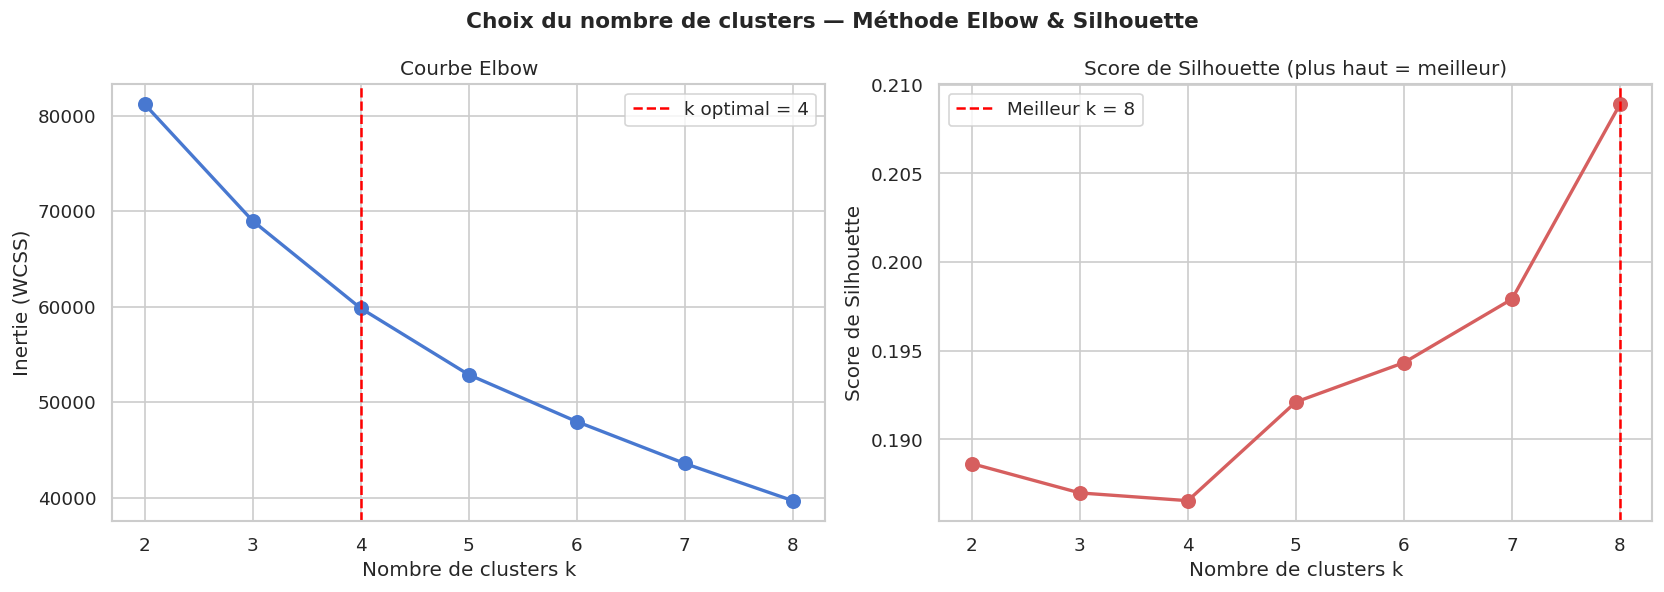


   → k optimal (Elbow)      : 4
   → k optimal (Silhouette) : 8
   → k retenu               : 8


In [40]:
# Visualisation Elbow + Silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Choix du nombre de clusters — Méthode Elbow & Silhouette",
             fontsize=13, fontweight='bold')

# Elbow
axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel("Nombre de clusters k")
axes[0].set_ylabel("Inertie (WCSS)")
axes[0].set_title("Courbe Elbow")
axes[0].set_xticks(list(K_range))

# Trouver le coude automatiquement
diffs  = np.diff(inertias)
diffs2 = np.diff(diffs)
k_opt  = list(K_range)[np.argmax(diffs2) + 2]  # +2 décalage indices

axes[0].axvline(x=k_opt, color='red', linestyle='--', linewidth=1.5,
                label=f'k optimal = {k_opt}')
axes[0].legend()

# Silhouette
axes[1].plot(list(K_range), silhouettes, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel("Nombre de clusters k")
axes[1].set_ylabel("Score de Silhouette")
axes[1].set_title("Score de Silhouette (plus haut = meilleur)")
axes[1].set_xticks(list(K_range))
best_k_sil = list(K_range)[np.argmax(silhouettes)]
axes[1].axvline(x=best_k_sil, color='red', linestyle='--', linewidth=1.5,
                label=f'Meilleur k = {best_k_sil}')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_08_elbow_silhouette.png', bbox_inches='tight')
plt.show()

print(f"\n   → k optimal (Elbow)      : {k_opt}")
print(f"   → k optimal (Silhouette) : {best_k_sil}")
K_FINAL = best_k_sil
print(f"   → k retenu               : {K_FINAL}")


In [41]:
# Entraînement K-Means final
print("\n" + "=" * 55)
print(f"CLUSTERING K-MEANS — k = {K_FINAL}")
print("=" * 55)

kmeans_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
df_km['cluster'] = kmeans_final.fit_predict(X_scaled)

# Ajouter les clusters au dataset principal
df_merged_final = df_merged_final.loc[df_km.index].copy()
df_merged_final['cluster'] = df_km['cluster'].values

print(f"   Inertie finale : {kmeans_final.inertia_:.1f}")
print(f"\n   Répartition des clusters :")
for c, cnt in df_km['cluster'].value_counts().sort_index().items():
    print(f"     Cluster {c} : {cnt:,} utilisateurs ({cnt/len(df_km)*100:.1f}%)")



CLUSTERING K-MEANS — k = 8
   Inertie finale : 39695.6

   Répartition des clusters :
     Cluster 0 : 3,329 utilisateurs (13.3%)
     Cluster 1 : 2,614 utilisateurs (10.5%)
     Cluster 2 : 3,279 utilisateurs (13.1%)
     Cluster 3 : 2,753 utilisateurs (11.0%)
     Cluster 4 : 3,242 utilisateurs (13.0%)
     Cluster 5 : 3,165 utilisateurs (12.7%)
     Cluster 6 : 3,326 utilisateurs (13.3%)
     Cluster 7 : 3,292 utilisateurs (13.2%)


In [42]:
# Profil moyen de chaque cluster
print("\n" + "=" * 55)
print("PROFIL MOYEN PAR CLUSTER")
print("=" * 55)

profils = df_km.groupby('cluster')[features_km].mean().round(2)
print(profils.to_string())

# Nommer les clusters selon leur profil
profil_labels = {}
for c in range(K_FINAL):
    row = profils.loc[c]
    if row['fare_amount'] < profils['fare_amount'].median():
        if row['rating'] >= profils['rating'].median():
            profil_labels[c] = "Économique satisfait"
        else:
            profil_labels[c] = "Économique insatisfait"
    else:
        if row['ride_distance_miles'] > profils['ride_distance_miles'].median():
            profil_labels[c] = "Premium longue distance"
        else:
            profil_labels[c] = "Premium courte distance"

print(f"\n   Labels attribués :")
for c, label in profil_labels.items():
    print(f"     Cluster {c} → '{label}'")



PROFIL MOYEN PAR CLUSTER
         fare_amount  ride_distance_miles  ride_duration_minutes  rating
cluster                                                                 
0              33.09                15.13                  29.56    4.22
1              73.00                14.38                  61.87    2.69
2              75.51                 6.33                  28.93    4.20
3              33.73                 6.30                  60.82    2.64
4              29.12                14.51                  95.75    4.06
5              78.57                15.67                  68.22    4.53
6              26.48                 4.93                  59.63    4.54
7              73.41                 5.51                  95.39    4.10

   Labels attribués :
     Cluster 0 → 'Économique satisfait'
     Cluster 1 → 'Premium longue distance'
     Cluster 2 → 'Premium courte distance'
     Cluster 3 → 'Économique insatisfait'
     Cluster 4 → 'Économique insatisfait'
     Cluste

In [ ]:
# Visualisation clusters
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f"Visualisation des {K_FINAL} Clusters — Segmentation utilisateurs",
             fontsize=14, fontweight='bold')

palette = sns.color_palette("Set1", K_FINAL)
cluster_labels_list = [profil_labels.get(i, f"Cluster {i}") for i in range(K_FINAL)]

sample_cl = df_km.sample(n=min(4000, len(df_km)), random_state=42)

# Prix vs Distance
for c in range(K_FINAL):
    mask = sample_cl['cluster'] == c
    axes[0,0].scatter(sample_cl.loc[mask,'ride_distance_miles'],
                      sample_cl.loc[mask,'fare_amount'],
                      alpha=0.4, s=10, color=palette[c],
                      label=profil_labels.get(c, f"Cluster {c}"))
axes[0,0].set_xlabel("Distance (miles)")
axes[0,0].set_ylabel("Prix")
axes[0,0].set_title("Prix vs Distance par cluster")
axes[0,0].legend(fontsize=8, markerscale=3)

# Prix vs Durée
for c in range(K_FINAL):
    mask = sample_cl['cluster'] == c
    axes[0,1].scatter(sample_cl.loc[mask,'ride_duration_minutes'],
                      sample_cl.loc[mask,'fare_amount'],
                      alpha=0.4, s=10, color=palette[c],
                      label=profil_labels.get(c, f"Cluster {c}"))
axes[0,1].set_xlabel("Durée (min)")
axes[0,1].set_ylabel("Prix")
axes[0,1].set_title("Prix vs Durée par cluster")

# Radar / Barplot profils
x      = np.arange(len(features_km))
width  = 0.8 / K_FINAL
profils_norm = (profils - profils.min()) / (profils.max() - profils.min())

for i, c in enumerate(range(K_FINAL)):
    offset = (i - K_FINAL/2 + 0.5) * width
    axes[1,0].bar(x + offset, profils_norm.loc[c], width,
                  label=profil_labels.get(c, f"Cluster {c}"),
                  color=palette[c], alpha=0.85, edgecolor='white')

axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(['Prix','Distance','Durée','Rating'], fontsize=10)
axes[1,0].set_ylabel("Valeur normalisée [0-1]")
axes[1,0].set_title("Profil normalisé par cluster")
axes[1,0].legend(fontsize=8)

# Répartition clusters (camembert)
sizes  = [df_km[df_km['cluster']==c].shape[0] for c in range(K_FINAL)]
explode = [0.05] * K_FINAL
axes[1,1].pie(sizes, labels=cluster_labels_list, autopct='%1.1f%%',
              colors=palette, explode=explode, startangle=140)
axes[1,1].set_title(f"Répartition des {K_FINAL} segments")

plt.tight_layout()
plt.savefig('eda_09_clusters_visualisation.png', bbox_inches='tight')
plt.show()

print("\n INSIGHT CLÉ — CLUSTERING")
print("   Ces segments représentent des profils d'utilisateurs distincts.")
print("   Le segment 'Économique' est le plus susceptible de migrer vers inDrive")
print("   (sensibilité au prix élevée, modèle de négociation attractif).")
print("   Le segment 'Premium' valorise la fiabilité Uber malgré un prix plus élevé.")


---
## 3.10 Analyse de la Saisonnalité et des Patterns Temporels

On analyse les variations de volume et de prix selon :
- L'heure de la journée (pointe matin/soir)
- Le jour de la semaine (semaine vs week-end)
- Le mois de l'année (saisonnalité, Ramadan, tourisme)

Ces patterns sont directement applicables au contexte marocain.

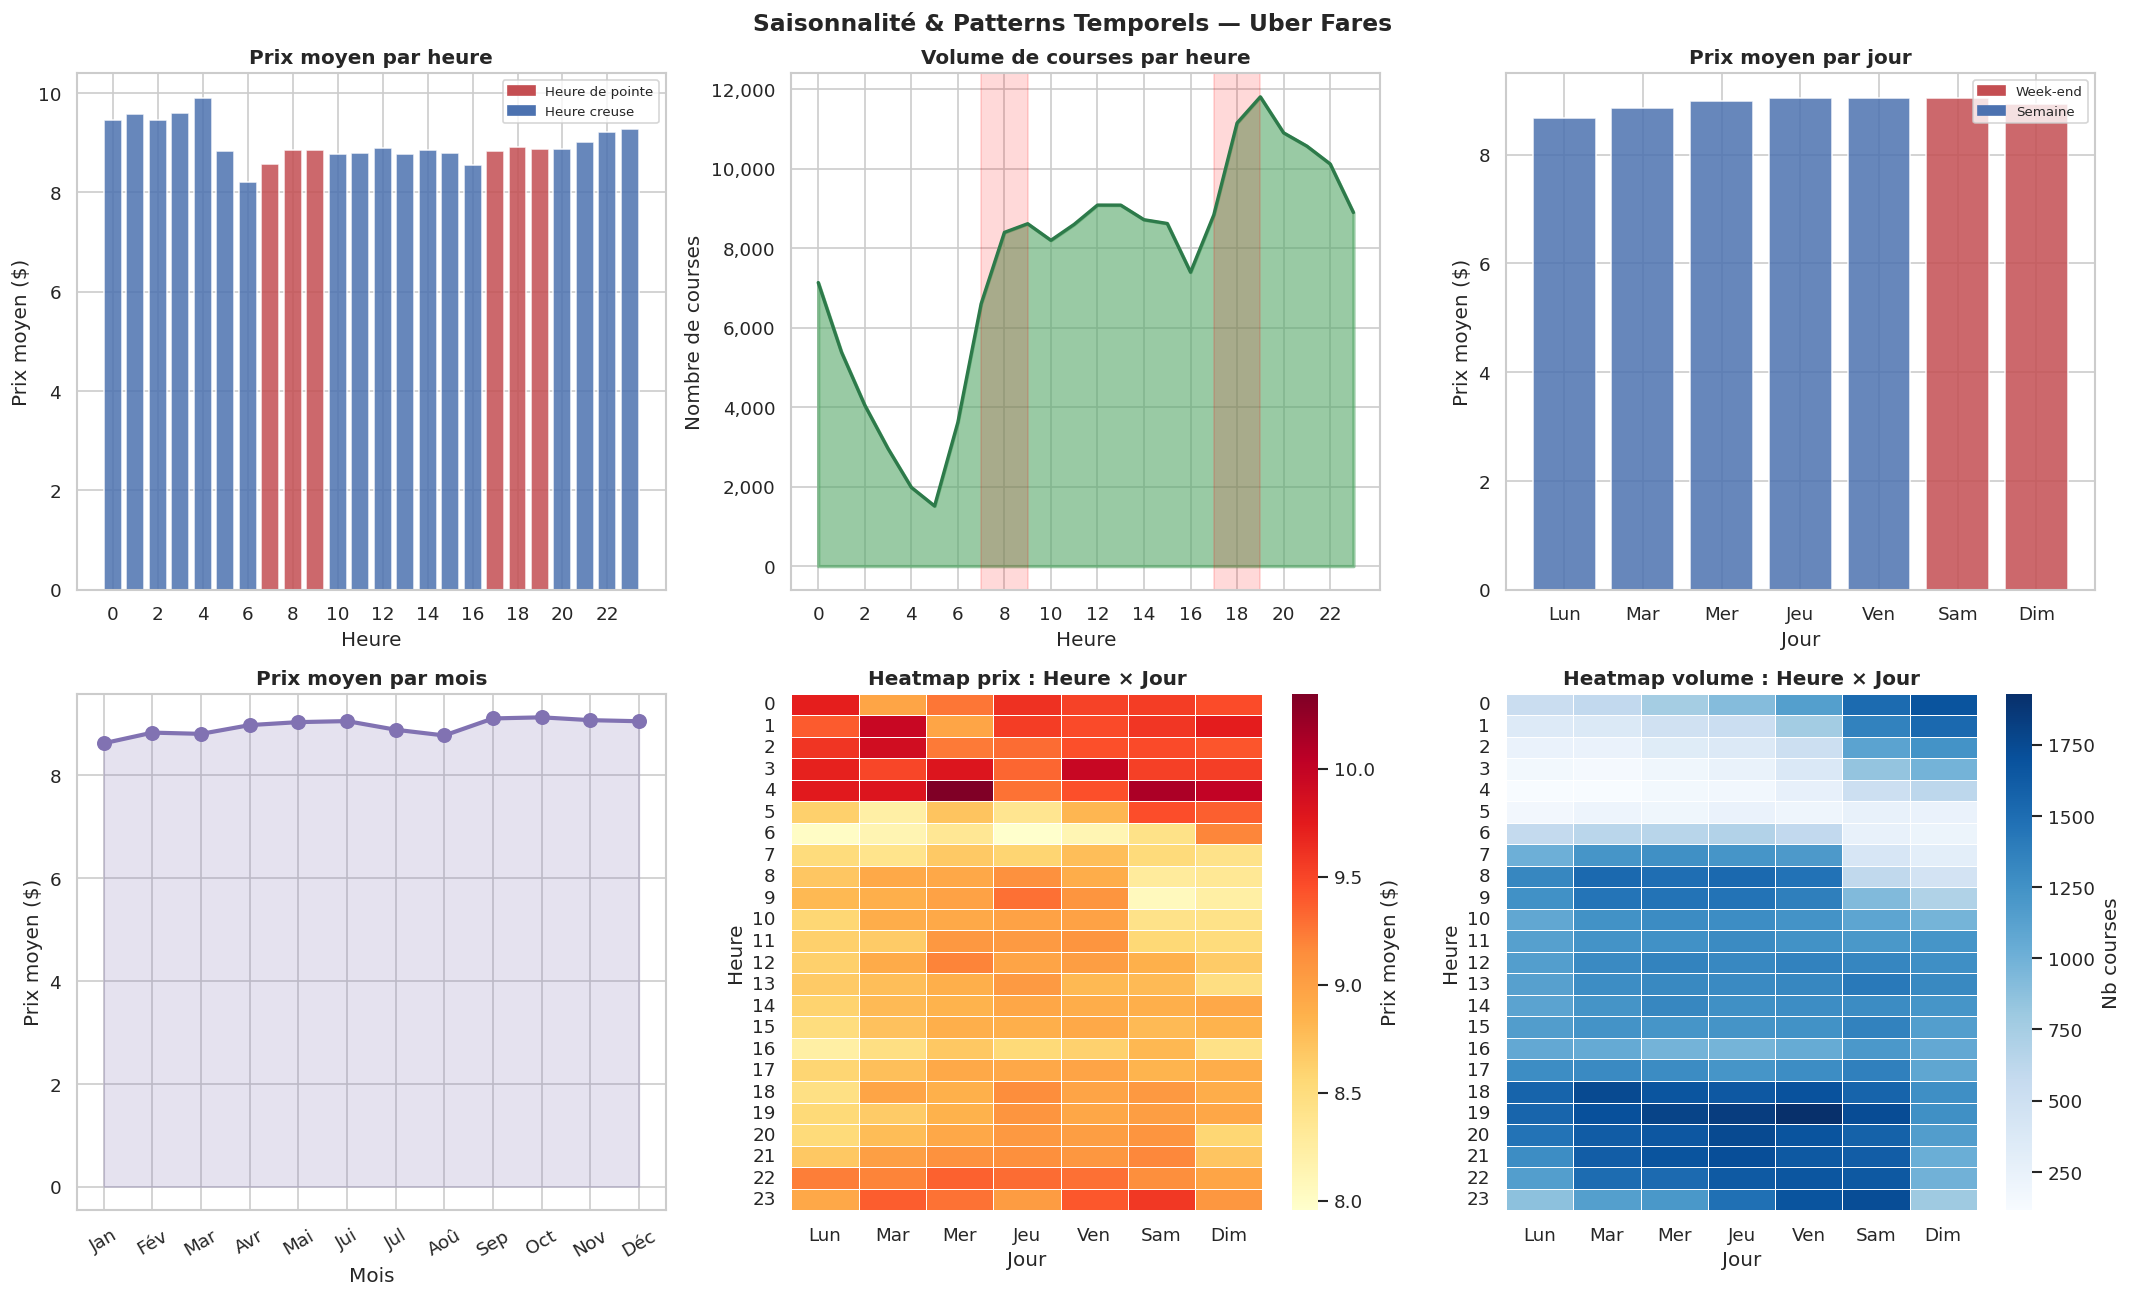

In [43]:
# Analyse temporelle complète Uber
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Saisonnalité & Patterns Temporels — Uber Fares",
             fontsize=14, fontweight='bold')

ORDER_JOURS = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
LABELS_FR   = ['Lun','Mar','Mer','Jeu','Ven','Sam','Dim']

# 1 — Prix moyen par heure
prix_heure = df_uber_final.groupby('hour')['fare_amount'].mean()
couleurs_h = ['#C44E52' if h in [7,8,9,17,18,19] else '#4C72B0' for h in prix_heure.index]
axes[0,0].bar(prix_heure.index, prix_heure.values, color=couleurs_h, edgecolor='white', alpha=0.85)
axes[0,0].set_title("Prix moyen par heure", fontweight='bold')
axes[0,0].set_xlabel("Heure")
axes[0,0].set_ylabel("Prix moyen ($)")
axes[0,0].set_xticks(range(0, 24, 2))
from matplotlib.patches import Patch
axes[0,0].legend(handles=[Patch(color='#C44E52', label='Heure de pointe'),
                           Patch(color='#4C72B0', label='Heure creuse')], fontsize=8)

# 2 — Volume par heure
vol_heure = df_uber_final['hour'].value_counts().sort_index()
axes[0,1].fill_between(vol_heure.index, vol_heure.values,
                        alpha=0.6, color='#55A868', linewidth=2)
axes[0,1].plot(vol_heure.index, vol_heure.values, color='#2d7a4a', linewidth=2)
axes[0,1].set_title("Volume de courses par heure", fontweight='bold')
axes[0,1].set_xlabel("Heure")
axes[0,1].set_ylabel("Nombre de courses")
axes[0,1].set_xticks(range(0, 24, 2))
axes[0,1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda v,_: f"{int(v):,}"))
axes[0,1].axvspan(7, 9, alpha=0.15, color='red')
axes[0,1].axvspan(17, 19, alpha=0.15, color='red')

# 3 — Prix moyen par jour
prix_jour = df_uber_final.groupby('day_of_week')['fare_amount'].mean().reindex(ORDER_JOURS)
couleurs_j = ['#C44E52' if j in ['Saturday','Sunday'] else '#4C72B0' for j in ORDER_JOURS]
axes[0,2].bar(LABELS_FR, prix_jour.values, color=couleurs_j, edgecolor='white', alpha=0.85)
axes[0,2].set_title("Prix moyen par jour", fontweight='bold')
axes[0,2].set_xlabel("Jour")
axes[0,2].set_ylabel("Prix moyen ($)")
axes[0,2].legend(handles=[Patch(color='#C44E52', label='Week-end'),
                           Patch(color='#4C72B0', label='Semaine')], fontsize=8)

# 4 — Prix moyen par mois
MOIS_FR = ['Jan','Fév','Mar','Avr','Mai','Jui','Jul','Aoû','Sep','Oct','Nov','Déc']
prix_mois = df_uber_final.groupby('month')['fare_amount'].mean()
axes[1,0].plot(prix_mois.index, prix_mois.values, 'o-',
               color='#8172B2', linewidth=2.5, markersize=8)
axes[1,0].fill_between(prix_mois.index, prix_mois.values,
                        alpha=0.2, color='#8172B2')
axes[1,0].set_title("Prix moyen par mois", fontweight='bold')
axes[1,0].set_xlabel("Mois")
axes[1,0].set_ylabel("Prix moyen ($)")
axes[1,0].set_xticks(prix_mois.index)
axes[1,0].set_xticklabels(MOIS_FR[:len(prix_mois)], rotation=30)

# 5 — Heatmap heure × jour (prix moyen)
pivot_prix = df_uber_final.pivot_table(
    values='fare_amount',
    index='hour',
    columns='day_of_week',
    aggfunc='mean'
).reindex(columns=ORDER_JOURS)

sns.heatmap(pivot_prix, ax=axes[1,1], cmap='YlOrRd',
            xticklabels=LABELS_FR, linewidths=0.3,
            cbar_kws={'label': 'Prix moyen ($)'})
axes[1,1].set_title("Heatmap prix : Heure × Jour", fontweight='bold')
axes[1,1].set_xlabel("Jour")
axes[1,1].set_ylabel("Heure")

# 6 — Heatmap heure × jour (volume)
pivot_vol = df_uber_final.pivot_table(
    values='fare_amount',
    index='hour',
    columns='day_of_week',
    aggfunc='count'
).reindex(columns=ORDER_JOURS)

sns.heatmap(pivot_vol, ax=axes[1,2], cmap='Blues',
            xticklabels=LABELS_FR, linewidths=0.3,
            cbar_kws={'label': 'Nb courses'})
axes[1,2].set_title("Heatmap volume : Heure × Jour", fontweight='bold')
axes[1,2].set_xlabel("Jour")
axes[1,2].set_ylabel("Heure")

plt.tight_layout()
plt.savefig('eda_10_saisonnalite.png', bbox_inches='tight')
plt.show()


---
## 3.11 Insights finaux EDA — Application au contexte Maroc

In [44]:
# Insights compilés
print("=" * 60)
print(" SYNTHÈSE COMPLÈTE — INSIGHTS EDA PHASE 3")
print("=" * 60)

heure_max_vol  = vol_heure.idxmax()
heure_max_prix = prix_heure.idxmax()
jour_max_prix  = prix_jour.idxmax()
mois_max_prix  = prix_mois.idxmax()

print(f"""
┌─────────────────────────────────────────────────────────┐
│  UBER FARES ({len(df_uber_final):,} courses après nettoyage)
├─────────────────────────────────────────────────────────┤
│  Prix moyen      : ${df_uber_final['fare_amount'].mean():.2f}
│  Heure de pointe : {heure_max_vol}h00 (volume max)
│  Heure prix max  : {heure_max_prix}h00
│  Jour prix max   : {jour_max_prix}
│  Mois prix max   : {mois_max_prix}
├─────────────────────────────────────────────────────────┤
│  RIDES + USERS ({len(df_merged_final):,} courses)
├─────────────────────────────────────────────────────────┤
│  Prix moyen      : {df_merged_final['fare_amount'].mean():.2f}
│  Distance moy.   : {df_merged_final['ride_distance_miles'].mean():.2f} miles
│  Durée moyenne   : {df_merged_final['ride_duration_minutes'].mean():.1f} min
│  Rating moyen    : {df_merged_final['rating'].mean():.2f} / 5
├─────────────────────────────────────────────────────────┤
│  APPLICATION CONTEXTE MAROC
├─────────────────────────────────────────────────────────┤
│  → Les heures de pointe (7-9h, 17-19h) sont les moments
│    où inDrive est le plus attractif (prix négocié = pas
│    de surge pricing). Uber perd des parts de marché sur
│    ces créneaux au Maroc.
│
│  → Les utilisateurs "économiques" (Cluster 0) sont les plus
│    à risque de migrer vers inDrive : sensibles au prix,
│    courses courtes, comportement typique de Casablanca /
│    Fès où inDrive est dominant.
│
│  → Le week-end (Sam/Dim) montre des prix plus élevés :
│    opportunité pour Uber de cibler la clientèle premium
│    (touristes, sorties nocturnes à Marrakech, Agadir).
│
│  → Rating moyen > 3.9 : la qualité de service perçue
│    est correcte — avantage Uber sur inDrive où les
│    chauffeurs sont moins vérifiés.
└─────────────────────────────────────────────────────────┘
""")

 SYNTHÈSE COMPLÈTE — INSIGHTS EDA PHASE 3

┌─────────────────────────────────────────────────────────┐
│  UBER FARES (182,136 courses après nettoyage)
├─────────────────────────────────────────────────────────┤
│  Prix moyen      : $8.94
│  Heure de pointe : 19h00 (volume max)
│  Heure prix max  : 4h00
│  Jour prix max   : Friday
│  Mois prix max   : 10
├─────────────────────────────────────────────────────────┤
│  RIDES + USERS (25,000 courses)
├─────────────────────────────────────────────────────────┤
│  Prix moyen      : 52.57
│  Distance moy.   : 10.29 miles
│  Durée moyenne   : 62.4 min
│  Rating moyen    : 3.93 / 5
├─────────────────────────────────────────────────────────┤
│  APPLICATION CONTEXTE MAROC
├─────────────────────────────────────────────────────────┤
│  → Les heures de pointe (7-9h, 17-19h) sont les moments
│    où inDrive est le plus attractif (prix négocié = pas
│    de surge pricing). Uber perd des parts de marché sur
│    ces créneaux au Maroc.
│
│  → Les utilisa

In [47]:
# Sauvegarde datasets finaux avec clusters
df_merged_final.to_csv('rides_merged_clustered.csv', index=False)
df_uber_final.to_csv('uber_final.csv', index=False)

print(" Fichiers sauvegardés pour la Phase 4 :")
print(f"   uber_final.csv           : {len(df_uber_final):,} lignes")
print(f"   rides_merged_clustered.csv : {len(df_merged_final):,} lignes (avec colonne 'cluster')")



 Fichiers sauvegardés pour la Phase 4 :
   uber_final.csv           : 182,136 lignes
   rides_merged_clustered.csv : 25,000 lignes (avec colonne 'cluster')
